# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu

# Notebook 04, Cumulative Ablation Study

## Notebook purpose

This notebook runs the **cumulative ablation study** for the skin lesion classification project.

Where `03_augmentation_experiments.ipynb` evaluates each augmentation family independently against the same-backbone baseline, this notebook evaluates the effect of **adding augmentation phases sequentially** within each backbone.

The cumulative ablation ladder is:

1. **baseline**  
   Resize, tensor conversion, and normalization only

2. **phase1_plus_2**  
   Baseline plus geometric augmentation

3. **phase1_plus_2_plus_3**  
   Baseline plus geometric augmentation plus color augmentation

4. **phase1_plus_2_plus_3_plus_4**  
   Baseline plus geometric augmentation plus color augmentation plus scale or crop augmentation, with CutMix applied in the training loop

The goal is to determine whether performance improves consistently as augmentation complexity is added, and whether those effects differ across:
- ResNet-50
- EfficientNet-B0
- DenseNet-121

This notebook reuses the same validated training and evaluation pipeline established earlier. The main change here is the **experimental controller**, not the core modeling logic.

## Execution structure

This notebook supports two execution modes:

### 1. Smoke-test mode
Used to verify that the full cumulative ablation pipeline works end to end on smaller stratified subsets.

### 2. Full mode
Used to run the full ISIC 2019 cumulative ablation study.

Because HPC access windows can be limited, the full experiment is designed to run **one backbone at a time**, rather than forcing all three CNN backbones through the full ablation ladder in a single session.

That means a typical full run now looks like:

- Session 1: ResNet-50 across all cumulative stages
- Session 2: EfficientNet-B0 across all cumulative stages
- Session 3: DenseNet-121 across all cumulative stages
- Final aggregation session: combine per-backbone results and generate summary plots

This keeps the scientific design unchanged while making the notebook practical for short HPC sessions.

In [1]:
SMOKE_MODE = True

ABLATION_STAGES = [
    "baseline",
    "phase1_plus_2",
    "phase1_plus_2_plus_3",
    "phase1_plus_2_plus_3_plus_4",
]

BACKBONES = [
    "resnet50",
    "efficientnet_b0",
    "densenet121",
]

SMOKE_TRAIN_FRACTION = 0.125
SMOKE_VAL_FRACTION = 0.25
SMOKE_MIN_TRAIN_PER_CLASS = 40
SMOKE_MIN_VAL_PER_CLASS = 15
SMOKE_MAX_TRAIN_PER_CLASS = 250
SMOKE_MAX_VAL_PER_CLASS = 75

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
FREEZE_FEATURES = False
SAVE_CHECKPOINTS = True

SMOKE_EPOCHS = 1
FULL_EPOCHS = 5
EPOCHS = SMOKE_EPOCHS if SMOKE_MODE else FULL_EPOCHS

EXPERIMENT_SEED = 42

## Imports and project-root setup

This section imports the core Python, PyTorch, and evaluation libraries used throughout the notebook, then resolves the project root so the notebook can consistently find the shared `scripts/` directory and project outputs.

The goal here is to make the notebook portable across local and HPC environments without changing any downstream experiment logic.

In [2]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

In [3]:
# Resolve the project root, not just the current notebook directory
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name.lower() == "code" else cwd
SCRIPTS = ROOT / "scripts"

if not SCRIPTS.exists():
    raise FileNotFoundError(f"Expected scripts directory at: {SCRIPTS}")

if str(SCRIPTS) not in sys.path:
    sys.path.append(str(SCRIPTS))

from resnet50_baseline import build_resnet50
from efficientnet_b0_baseline import build_efficientnet_b0
from densenet121_baseline import build_densenet121

from phase2_geometric import get_phase2_block
from phase3_color import get_phase3_block
from phase4_scale_crop import get_phase4_block, cutmix_data, cutmix_loss

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CWD:", cwd)
print("ROOT:", ROOT)
print("SCRIPTS:", SCRIPTS)
print("DEVICE:", DEVICE)

CWD: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/Code
ROOT: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire
SCRIPTS: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/scripts
DEVICE: cuda


## Save experiment configuration and set seeds

This section creates the output directories for the notebook, saves the active experiment configuration, and fixes the random seed for reproducibility.

Because the setup section is run once at the top of the notebook, the saved configuration should describe the overall notebook environment, not a single backbone-specific HPC session. Backbone-specific execution choices will be handled later in the run cells.

In [4]:
OUT_ROOT = ROOT / "outputs"

CONFIG_DIR = OUT_ROOT / "configs" / "04_ablation_study"
FIG_DIR = OUT_ROOT / "figures" / "04_ablation_study"
METRIC_DIR = OUT_ROOT / "metrics"
PRED_DIR = OUT_ROOT / "preds"
CKPT_DIR = OUT_ROOT / "checkpoints"
REPORT_DIR = OUT_ROOT / "reports" / "04_ablation_study"

for d in [CONFIG_DIR, FIG_DIR, METRIC_DIR, PRED_DIR, CKPT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG = {
    "notebook": "04_ablation_study",
    "seed": EXPERIMENT_SEED,
    "smoke_mode": SMOKE_MODE,
    "ablation_stages": ABLATION_STAGES,
    "backbones": BACKBONES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "freeze_features": FREEZE_FEATURES,
    "save_checkpoints": SAVE_CHECKPOINTS,
    "num_workers": NUM_WORKERS,
}

config_path = CONFIG_DIR / ("smoke_config.json" if SMOKE_MODE else "full_config.json")

with open(config_path, "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(EXPERIMENT_SEED)

loader_generator = torch.Generator()
loader_generator.manual_seed(EXPERIMENT_SEED)

print("Saved config to:", config_path)
print("Global seed set.")
print("DataLoader generator seeded.")

Saved config to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/configs/04_ablation_study/smoke_config.json
Global seed set.
DataLoader generator seeded.


## Locate and load processed ISIC 2019 splits

This section loads the processed train and validation splits prepared earlier in the project pipeline.

The notebook expects the processed CSV files and class-weight JSON file to already exist under `DATA/processed/`. A small path-normalization helper is used so the image paths behave consistently across Windows, Linux, and Rivanna environments.

In [5]:
DATA = ROOT / "DATA"
PROCESSED = DATA / "processed"

train_csv = PROCESSED / "isic2019" / "train.csv"
val_csv = PROCESSED / "isic2019" / "val.csv"
weights_json = PROCESSED / "class_weights.json"

print("train_csv exists:", train_csv.exists())
print("val_csv exists:", val_csv.exists())
print("weights_json exists:", weights_json.exists())

if not train_csv.exists():
    raise FileNotFoundError(f"Could not find train split CSV: {train_csv}")
if not val_csv.exists():
    raise FileNotFoundError(f"Could not find validation split CSV: {val_csv}")
if not weights_json.exists():
    raise FileNotFoundError(f"Could not find class weight JSON: {weights_json}")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

def normalize_path_column(df, col):
    df = df.copy()
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("\\", "/", regex=False)
    return df

train_df = normalize_path_column(train_df, "image_path")
val_df = normalize_path_column(val_df, "image_path")

required_cols = ["image_path", "label"]
for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing required column in train_df: {col}")
    if col not in val_df.columns:
        raise ValueError(f"Missing required column in val_df: {col}")

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("\ntrain_df columns:")
print(train_df.columns.tolist())

train_csv exists: True
val_csv exists: True
weights_json exists: True
train_df shape: (21531, 21)
val_df shape: (3800, 21)

train_df columns:
['image_id', 'label', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex', 'is_malignant', 'image_path', 'age_scaled', 'sex_female', 'sex_male', 'sex_unknown', 'anatom_site_general_anterior torso', 'anatom_site_general_head/neck', 'anatom_site_general_lateral torso', 'anatom_site_general_lower extremity', 'anatom_site_general_oral/genital', 'anatom_site_general_palms/soles', 'anatom_site_general_posterior torso', 'anatom_site_general_unknown', 'anatom_site_general_upper extremity']


## Encode labels and class weights

This section maps the string lesion labels to integer class indices and loads the class-weight vector used in the weighted cross-entropy loss.

The label mapping is created from the training split and then applied consistently to both the training and validation data. This keeps the class order stable across model training, evaluation, confusion matrices, and saved reports.

In [6]:
labels = sorted(train_df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_df["label_idx"] = train_df["label"].map(label_to_idx)
val_df["label_idx"] = val_df["label"].map(label_to_idx)

with open(weights_json, "r") as f:
    class_weights_dict = json.load(f)

missing_weight_labels = [label for label in labels if label not in class_weights_dict]
if missing_weight_labels:
    raise ValueError(
        f"Missing class weights for labels: {missing_weight_labels}"
    )

class_weight_tensor = torch.tensor(
    [class_weights_dict[label] for label in labels],
    dtype=torch.float32,
    device=DEVICE,
)

print("Labels:", labels)
print("label_to_idx:", label_to_idx)
print("idx_to_label:", idx_to_label)
print("Class weights tensor:", class_weight_tensor)

Labels: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
label_to_idx: {'AK': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'SCC': 6, 'VASC': 7}
idx_to_label: {0: 'AK', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'MEL', 5: 'NV', 6: 'SCC', 7: 'VASC'}
Class weights tensor: tensor([ 3.6518,  0.9530,  1.2069, 13.2580,  0.7001,  0.2459,  5.0400, 12.5180],
       device='cuda:0')


## Build stratified smoke-test subsets

This section creates smaller stratified training and validation subsets for smoke-mode execution.

The purpose of the smoke subset is not to estimate final model performance. Instead, it provides a fast way to verify that the full cumulative ablation pipeline works end to end:

- data loading
- cumulative dataset construction
- augmentation staging
- training and evaluation loops
- artifact writing
- plotting and summary generation

When `SMOKE_MODE = False`, the notebook switches back to the full processed ISIC 2019 train and validation splits without changing the rest of the pipeline.

In [7]:
def make_stratified_smoke_subset(
    df: pd.DataFrame,
    label_col: str,
    frac: float,
    min_per_class: int,
    max_per_class: int,
    seed: int = 42,
) -> pd.DataFrame:
    parts = []

    for _, group in df.groupby(label_col):
        n_total = len(group)
        n_take = max(min_per_class, int(round(n_total * frac)))
        n_take = min(n_take, max_per_class, n_total)

        sampled = group.sample(n=n_take, random_state=seed)
        parts.append(sampled)

    out = (
        pd.concat(parts, axis=0)
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )
    return out


if SMOKE_MODE:
    train_run_df = make_stratified_smoke_subset(
        train_df,
        label_col="label",
        frac=SMOKE_TRAIN_FRACTION,
        min_per_class=SMOKE_MIN_TRAIN_PER_CLASS,
        max_per_class=SMOKE_MAX_TRAIN_PER_CLASS,
        seed=EXPERIMENT_SEED,
    )

    val_run_df = make_stratified_smoke_subset(
        val_df,
        label_col="label",
        frac=SMOKE_VAL_FRACTION,
        min_per_class=SMOKE_MIN_VAL_PER_CLASS,
        max_per_class=SMOKE_MAX_VAL_PER_CLASS,
        seed=EXPERIMENT_SEED,
    )
else:
    train_run_df = train_df.copy()
    val_run_df = val_df.copy()

print("train_run_df shape:", train_run_df.shape)
print("val_run_df shape:", val_run_df.shape)

print("\ntrain_run_df class counts:")
print(train_run_df["label"].value_counts().sort_index())

print("\nval_run_df class counts:")
print(val_run_df["label"].value_counts().sort_index())

train_run_df shape: (1239, 22)
val_run_df shape: (386, 22)

train_run_df class counts:
label
AK       92
BCC     250
BKL     250
DF       40
MEL     250
NV      250
SCC      67
VASC     40
Name: count, dtype: int64

val_run_df class counts:
label
AK      32
BCC     75
BKL     75
DF      15
MEL     75
NV      75
SCC     24
VASC    15
Name: count, dtype: int64


## Dataset and transform setup

This section defines the dataset wrapper and the transform pipelines used in the cumulative ablation study.

The key transform rule is:

- augmentation must happen in image space
- tensor conversion and normalization must happen afterward
- validation remains strictly non-augmented

This keeps the cumulative ablation study aligned with the intended augmentation design and makes the stage logic easier to describe later in the written report.

In [8]:
class ISICDataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.root = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = str(row["image_path"]).replace("\\", "/")
        image = Image.open(self.root / rel_path).convert("RGB")
        label = int(row["label_idx"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, rel_path

In [9]:
def make_baseline_transforms(image_size=224):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )

    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_tf, val_tf

### Transform ordering note

For all phase-specific transforms, image-space augmentation must occur before tensor conversion and normalization.

Accordingly:

- **Phase 2** inserts geometric augmentation after `Resize` and before `ToTensor()` and normalization
- **Phase 3** inserts color augmentation after `Resize` and before `ToTensor()` and normalization
- **Phase 4** inserts scale or crop augmentation after `Resize` and before `ToTensor()` and normalization

Validation uses the strict baseline transform only.

This ordering preserves the intended behavior of the torchvision augmentation operators and keeps the cumulative ablation pipeline consistent with the project design.

In [10]:
STAGE_TO_PHASES = {
    "baseline": ["phase1"],
    "phase1_plus_2": ["phase1", "phase2"],
    "phase1_plus_2_plus_3": ["phase1", "phase2", "phase3"],
    "phase1_plus_2_plus_3_plus_4": ["phase1", "phase2", "phase3", "phase4"],
}


def get_active_phases(stage_name):
    if stage_name not in STAGE_TO_PHASES:
        raise ValueError(f"Unknown stage_name: {stage_name}")
    return STAGE_TO_PHASES[stage_name]


def make_stage_train_transform(stage_name, image_size=224):
    active_phases = get_active_phases(stage_name)

    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )

    ops = [transforms.Resize((image_size, image_size))]

    if "phase2" in active_phases:
        ops.append(get_phase2_block())

    if "phase3" in active_phases:
        ops.append(
            get_phase3_block(
                brightness=0.2,
                contrast=0.2,
                hue=0.1,
                saturation=0.2,
            )
        )

    if "phase4" in active_phases:
        ops.append(
            get_phase4_block(
                size=image_size,
                scale=(0.7, 1.0),
                ratio=(3 / 4, 4 / 3),
            )
        )

    ops.extend([
        transforms.ToTensor(),
        normalize,
    ])

    return transforms.Compose(ops)


def make_baseline_transforms(image_size=224):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )

    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_tf, val_tf


In [11]:
baseline_train_tf, val_tf = make_baseline_transforms(IMAGE_SIZE)

print("Stage transform summary:")
for stage_name in ABLATION_STAGES:
    stage_tf = make_stage_train_transform(stage_name, IMAGE_SIZE)
    print(f"  {stage_name}: {' + '.join(get_active_phases(stage_name))}")
    print(f"    transform: {stage_tf}")

sample_baseline_ds = ISICDataset(train_run_df, ROOT, transform=baseline_train_tf)
sample_img, sample_label, sample_path = sample_baseline_ds[0]

print("\nSample baseline tensor shape:", sample_img.shape)
print("Sample baseline label index:", sample_label)
print("Sample baseline label name:", idx_to_label[sample_label])
print("Sample baseline path:", sample_path)


Stage transform summary:
  baseline: phase1
    transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
  phase1_plus_2: phase1 + phase2
    transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomChoice(
    RandomHorizontalFlip(p=1.0)
    RandomVerticalFlip(p=1.0)
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], shear=[-10.0, 10.0])
)(p=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
  phase1_plus_2_plus_3: phase1 + phase2 + phase3
    transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomChoice(
    RandomHorizontalFlip(p=1.0)
    RandomVerticalFlip(p=1.0)
    RandomRotation(degrees=[-90.0, 90.0], interpolation=nearest, e

## Cumulative ablation dataset construction

Notebook 04 uses **one training dataset per stage**. The stage controls which augmentation blocks are applied inside the transform pipeline, not how many copies of the dataset are added.

That means the cumulative ladder is implemented as:

- `baseline`: Phase 1 transform only
- `phase1_plus_2`: Phase 1 transform plus Phase 2 geometric augmentation
- `phase1_plus_2_plus_3`: Phase 1 transform plus Phase 2 geometric augmentation plus Phase 3 color augmentation
- `phase1_plus_2_plus_3_plus_4`: Phase 1 transform plus Phase 2 geometric augmentation plus Phase 3 color augmentation plus Phase 4 scale/crop augmentation, with CutMix applied in the training loop

The training row count should remain equal to `len(train_run_df)` for every stage. Augmentation is applied stochastically as images are loaded, so the model sees transformed versions of the same training split without expanding the dataset size.

Validation remains non-augmented throughout.


In [12]:
def make_stage_datasets(stage_name):
    train_tf = make_stage_train_transform(stage_name, IMAGE_SIZE)
    train_ds = ISICDataset(train_run_df, ROOT, transform=train_tf)

    active_phases = get_active_phases(stage_name)
    use_cutmix = stage_name == "phase1_plus_2_plus_3_plus_4"

    return train_ds, use_cutmix, active_phases


In [13]:
def make_stage_loaders(stage_name):
    train_ds, use_cutmix, active_phases = make_stage_datasets(stage_name)

    val_ds = ISICDataset(val_run_df, ROOT, transform=val_tf)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=loader_generator,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    return train_ds, val_ds, train_loader, val_loader, use_cutmix, active_phases


## Training and evaluation utilities

This section defines the shared training and evaluation functions used by both smoke-mode and full cumulative ablation runs.

The training loop supports optional CutMix during the final cumulative stage, while the evaluation loop computes the main project metrics and saves the information needed for later report writing:

- validation loss
- balanced accuracy
- macro AUC
- per-class AUC
- confusion matrices
- classification reports
- prediction-level outputs

These utilities are reused across all backbones and cumulative stages so that the experiment controller changes, but the core training and evaluation logic remains consistent.

In [14]:
def maybe_apply_cutmix(x, y, cutmix_prob=0.5, alpha=1.0):
    if alpha <= 0:
        return x, y, y, 1.0
    if np.random.rand() > cutmix_prob:
        return x, y, y, 1.0
    return cutmix_data(x, y, alpha=alpha)


def train_one_epoch(model, loader, criterion, optimizer, device, use_cutmix=False):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for images, targets, _ in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        if use_cutmix:
            images, y_a, y_b, lam = maybe_apply_cutmix(
                images,
                targets,
                cutmix_prob=0.5,
                alpha=1.0,
            )
            logits = model(images)
            loss = cutmix_loss(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(images)
            loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_samples = 0

    all_targets = []
    all_preds = []
    all_probs = []
    all_paths = []

    for images, targets, paths in loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

    avg_loss = running_loss / max(n_samples, 1)
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        macro_auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro",
        )
    except ValueError:
        macro_auc = np.nan

    per_class_auc = {}
    for i, label in enumerate(labels):
        try:
            per_class_auc[label] = roc_auc_score(
                (y_true == i).astype(int),
                y_prob[:, i],
            )
        except ValueError:
            per_class_auc[label] = np.nan

    preds_df = pd.DataFrame({
        "rel_path": all_paths,
        "y_true_idx": y_true,
        "y_pred_idx": y_pred,
        "y_true_label": [idx_to_label[i] for i in y_true],
        "y_pred_label": [idx_to_label[i] for i in y_pred],
    })

    cm_counts = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(labels))),
    )

    cm_row_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(labels))),
        normalize="true",
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(labels))),
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "balanced_accuracy": bal_acc,
        "macro_auc": macro_auc,
        "per_class_auc": per_class_auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "paths": all_paths,
        "preds_df": preds_df,
        "cm_counts": cm_counts,
        "cm_row_norm": cm_row_norm,
        "classification_report": report_dict,
    }

## Model builders

This section maps the backbone names used in the experiment controller to the corresponding model-construction functions imported from the shared project scripts.

Keeping this mapping centralized makes it easier to run the same cumulative ablation logic across ResNet-50, EfficientNet-B0, and DenseNet-121 without changing the training code itself.

In [15]:
MODEL_BUILDERS = {
    "resnet50": build_resnet50,
    "efficientnet_b0": build_efficientnet_b0,
    "densenet121": build_densenet121,
}

## Plotting helpers

This section defines the reusable plotting functions for loss curves, validation metric histories, and confusion matrices.

These plots are generated at the experiment level so that each backbone-stage run produces artifacts that can later support both notebook inspection and the final written report.

In [16]:
def plot_history(history_df, backbone, stage_name, fig_dir):
    tag = f"{backbone}_{stage_name}"

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{tag} loss history")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_loss_history.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(
        history_df["epoch"],
        history_df["val_balanced_accuracy"],
        marker="o",
        label="Val balanced accuracy",
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_macro_auc"],
        marker="o",
        label="Val macro AUC",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title(f"{tag} validation metrics")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_val_metrics_history.png", dpi=200, bbox_inches="tight")
    plt.show()


def plot_confusion_matrices(cm_counts, cm_row_norm, backbone, stage_name, fig_dir):
    tag = f"{backbone}_{stage_name}"
    tick_marks = np.arange(len(labels))

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_counts, interpolation="nearest")
    plt.title(f"{tag} confusion matrix (counts)")
    plt.colorbar()
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    for i in range(cm_counts.shape[0]):
        for j in range(cm_counts.shape[1]):
            plt.text(
                j,
                i,
                str(cm_counts[i, j]),
                ha="center",
                va="center",
                fontsize=8,
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_confusion_matrix_counts.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_row_norm, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"{tag} confusion matrix (row-normalized)")
    plt.colorbar()
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    for i in range(cm_row_norm.shape[0]):
        for j in range(cm_row_norm.shape[1]):
            plt.text(
                j,
                i,
                f"{cm_row_norm[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_confusion_matrix_row_norm.png", dpi=200, bbox_inches="tight")
    plt.show()

## Experiment runner

This section defines the experiment runners used for both smoke-mode and full-data cumulative ablation studies.

The notebook supports two levels of execution:

1. **Single experiment execution**  
   Run one backbone on one cumulative phase for a chosen number of epochs.

2. **Backbone suite execution**  
   Run one backbone across the full cumulative ladder for a chosen number of epochs.

This makes the notebook flexible for HPC usage. A full backbone can be run in one session when time allows, while individual backbone-phase cells can be used when a more granular execution strategy is needed.

In [17]:
def run_ablation_experiment(backbone, stage_name, epochs=None):
    if epochs is None:
        epochs = EPOCHS

    print("=" * 90)
    print(f"Running backbone={backbone}, stage={stage_name}, epochs={epochs}")
    print("=" * 90)

    train_ds, val_ds, train_loader, val_loader, use_cutmix, active_phases = make_stage_loaders(stage_name)

    print("Active phases:", " + ".join(active_phases))
    print("Train size:", len(train_ds))
    print("Validation size:", len(val_ds))
    print("Use CutMix:", use_cutmix)

    build_fn = MODEL_BUILDERS[backbone]
    model = build_fn(
        num_classes=len(labels),
        pretrained=True,
        freeze_backbone=FREEZE_FEATURES,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = {
        "epoch": [],
        "epoch_seconds": [],
        "train_loss": [],
        "val_loss": [],
        "val_balanced_accuracy": [],
        "val_macro_auc": [],
    }

    best_score = -np.inf
    tag = f"{backbone}_{stage_name}"
    best_ckpt_path = CKPT_DIR / f"{tag}_best.pt"
    history_path = METRIC_DIR / f"{tag}_history.csv"
    pred_path = PRED_DIR / f"{tag}_predictions.csv"
    report_path = REPORT_DIR / f"{tag}_classification_report.json"

    best_preds_df = None
    best_cm_counts = None
    best_cm_row_norm = None
    best_report_dict = None
    best_epoch = None
    best_val_loss = None
    best_val_bal_acc = None
    best_val_macro_auc = None
    best_per_class_auc = None

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
            use_cutmix=use_cutmix,
        )

        val_metrics = evaluate(model, val_loader, criterion, DEVICE)
        epoch_seconds = time.time() - epoch_start

        current_score = val_metrics["macro_auc"]
        if np.isnan(current_score):
            current_score = val_metrics["balanced_accuracy"]

        if current_score > best_score:
            best_score = current_score
            best_preds_df = val_metrics["preds_df"].copy()
            best_cm_counts = val_metrics["cm_counts"].copy()
            best_cm_row_norm = val_metrics["cm_row_norm"].copy()
            best_report_dict = val_metrics["classification_report"].copy()
            best_per_class_auc = val_metrics["per_class_auc"].copy()
            best_epoch = epoch
            best_val_loss = float(val_metrics["loss"])
            best_val_bal_acc = float(val_metrics["balanced_accuracy"])
            best_val_macro_auc = float(val_metrics["macro_auc"])

            if SAVE_CHECKPOINTS:
                torch.save(
                    {
                        "epoch": epoch,
                        "epochs_requested": epochs,
                        "model_state_dict": model.state_dict(),
                        "label_to_idx": label_to_idx,
                        "backbone": backbone,
                        "stage_name": stage_name,
                        "active_phases": active_phases,
                        "augmentation_mode": "on_the_fly_cumulative_transform",
                        "image_size": IMAGE_SIZE,
                        "smoke_mode": SMOKE_MODE,
                    },
                    best_ckpt_path,
                )

        history["epoch"].append(epoch)
        history["epoch_seconds"].append(epoch_seconds)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_auc"].append(val_metrics["macro_auc"])

        print(
            f"{backbone} | {stage_name} | Epoch {epoch:02d}/{epochs:02d} | "
            f"train_size={len(train_ds)} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
            f"val_macro_auc={val_metrics['macro_auc']:.4f} | "
            f"epoch_time={epoch_seconds/60:.2f} min"
        )

    history_df = pd.DataFrame(history)
    history_df["backbone"] = backbone
    history_df["stage"] = stage_name
    history_df["epochs_requested"] = epochs
    history_df.to_csv(history_path, index=False)

    if best_preds_df is not None:
        best_preds_df.to_csv(pred_path, index=False)

    if best_report_dict is not None:
        with open(report_path, "w") as f:
            json.dump(best_report_dict, f, indent=2)

    plot_history(history_df, backbone, stage_name, FIG_DIR)

    if best_cm_counts is not None and best_cm_row_norm is not None:
        plot_confusion_matrices(
            best_cm_counts,
            best_cm_row_norm,
            backbone,
            stage_name,
            FIG_DIR,
        )

    result = {
        "backbone": backbone,
        "stage": stage_name,
        "epochs_requested": epochs,
        "train_size": len(train_ds),
        "combined_train_size": len(train_ds),
        "val_size": len(val_ds),
        "active_phases": "+".join(active_phases),
        "augmentation_mode": "on_the_fly_cumulative_transform",
        "use_cutmix": use_cutmix,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_balanced_accuracy": best_val_bal_acc,
        "best_val_macro_auc": best_val_macro_auc,
        "auc_AK": best_per_class_auc["AK"],
        "auc_BCC": best_per_class_auc["BCC"],
        "auc_BKL": best_per_class_auc["BKL"],
        "auc_DF": best_per_class_auc["DF"],
        "auc_MEL": best_per_class_auc["MEL"],
        "auc_NV": best_per_class_auc["NV"],
        "auc_SCC": best_per_class_auc["SCC"],
        "auc_VASC": best_per_class_auc["VASC"],
        "history_path": str(history_path),
        "pred_path": str(pred_path),
        "report_path": str(report_path),
        "checkpoint_path": str(best_ckpt_path),
    }

    return result


def run_backbone_ablation_suite(backbone, epochs=5, save_suffix=None):
    print("#" * 100)
    print(f"Running cumulative ablation suite for backbone={backbone}, epochs={epochs}")
    print("#" * 100)

    backbone_rows = []

    for stage_name in ABLATION_STAGES:
        result = run_ablation_experiment(
            backbone=backbone,
            stage_name=stage_name,
            epochs=epochs,
        )
        backbone_rows.append(result)

    backbone_results_df = pd.DataFrame(backbone_rows)
    display(backbone_results_df)

    if save_suffix is None:
        save_suffix = "smoke" if SMOKE_MODE else "full"

    out_path = METRIC_DIR / f"{backbone}_ablation_{save_suffix}_comparison.csv"
    backbone_results_df.to_csv(out_path, index=False)

    print("Saved backbone summary to:", out_path)
    return backbone_results_df

## Smoke-test cumulative ablation run

This section runs the cumulative ablation study in smoke mode.

Because the smoke subset is intentionally small, it is still reasonable to run all three backbones sequentially in one notebook block. The purpose here is rapid end-to-end verification of the cumulative pipeline rather than final model comparison.

Running backbone=resnet50, stage=baseline, epochs=1
Active phases: phase1
Train size: 1239
Validation size: 386
Use CutMix: False
resnet50 | baseline | Epoch 01/01 | train_size=1239 | train_loss=1.9500 | val_loss=1.7413 | val_bal_acc=0.2981 | val_macro_auc=0.7278 | epoch_time=0.37 min


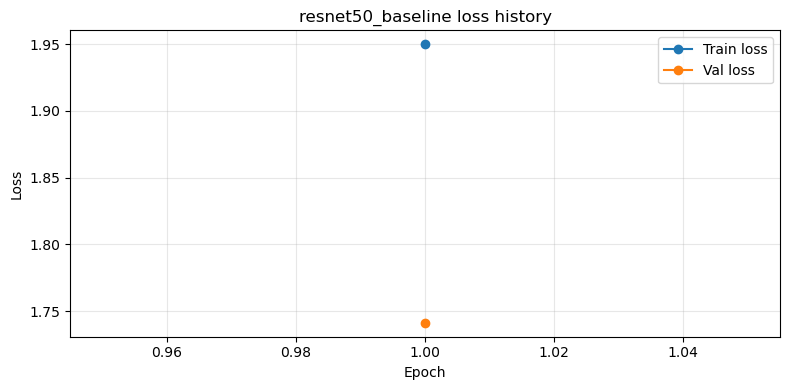

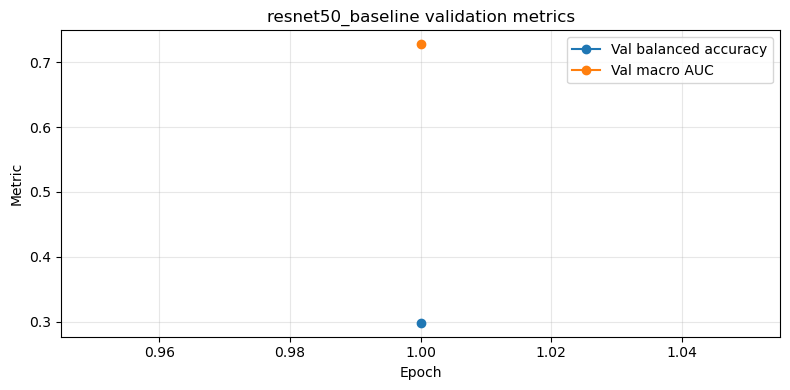

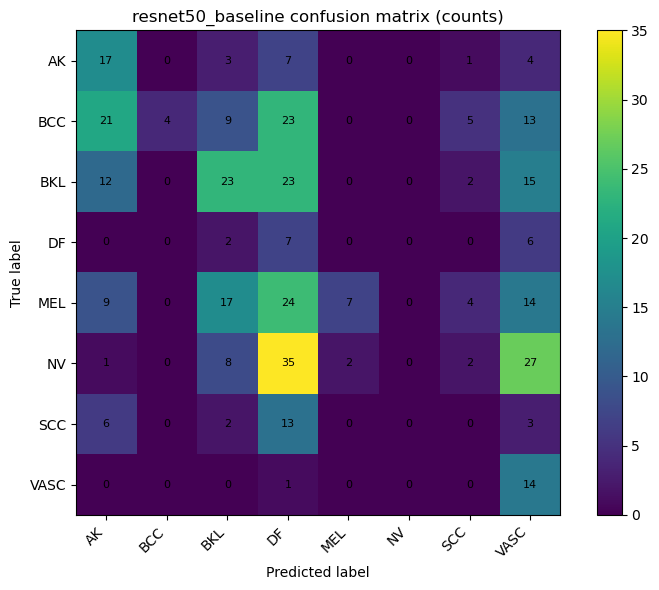

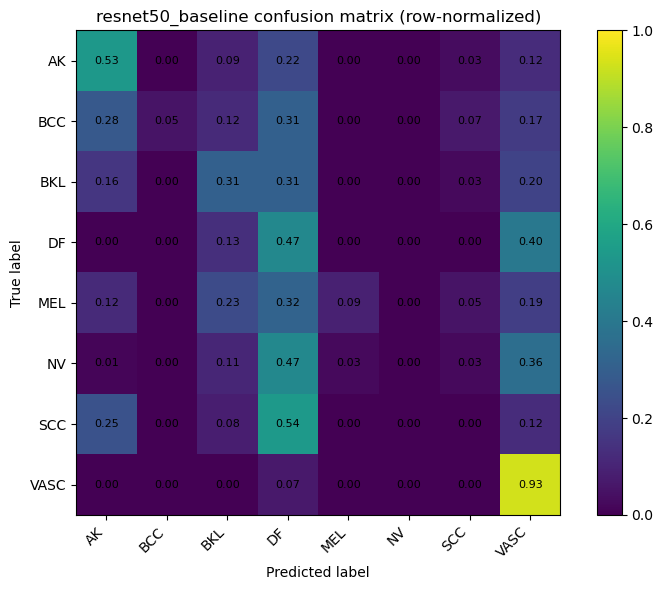

Running backbone=resnet50, stage=phase1_plus_2, epochs=1
Active phases: phase1 + phase2
Train size: 1239
Validation size: 386
Use CutMix: False
resnet50 | phase1_plus_2 | Epoch 01/01 | train_size=1239 | train_loss=1.9721 | val_loss=1.7759 | val_bal_acc=0.3001 | val_macro_auc=0.7252 | epoch_time=0.35 min


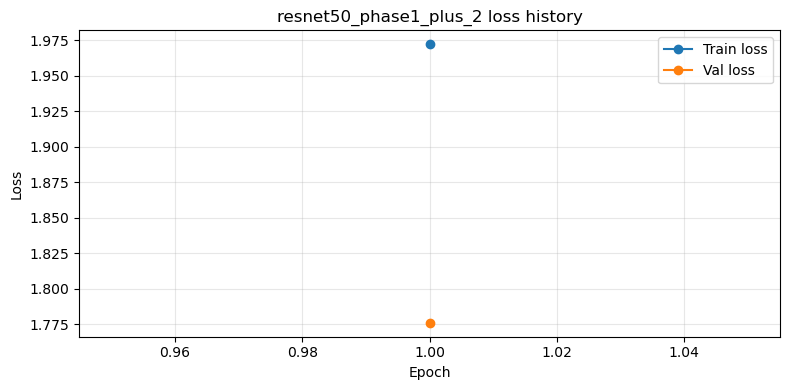

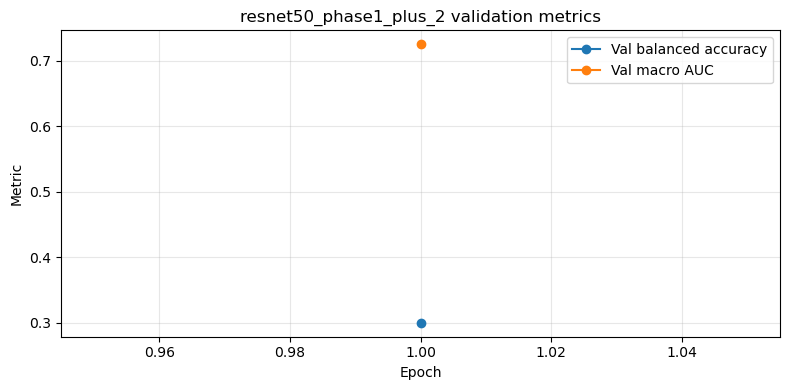

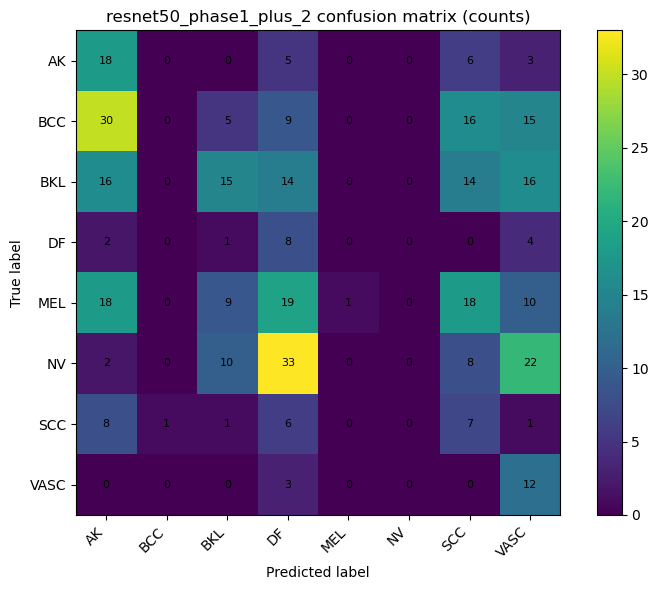

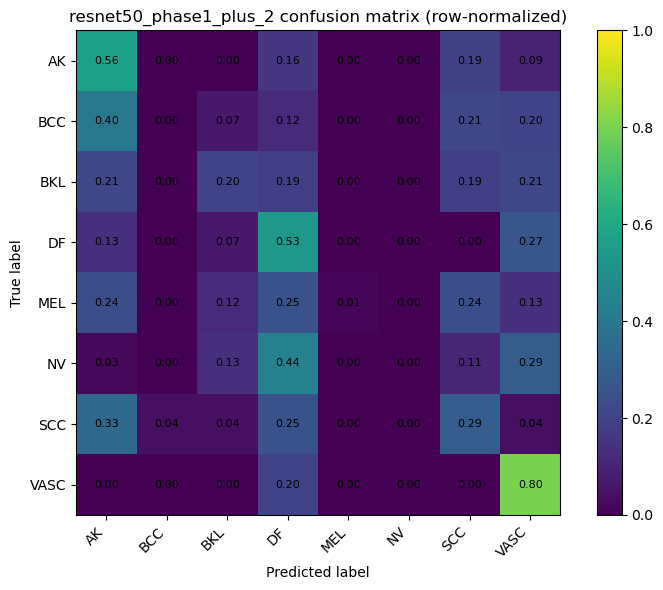

Running backbone=resnet50, stage=phase1_plus_2_plus_3, epochs=1
Active phases: phase1 + phase2 + phase3
Train size: 1239
Validation size: 386
Use CutMix: False
resnet50 | phase1_plus_2_plus_3 | Epoch 01/01 | train_size=1239 | train_loss=1.9893 | val_loss=1.8091 | val_bal_acc=0.2941 | val_macro_auc=0.7169 | epoch_time=0.37 min


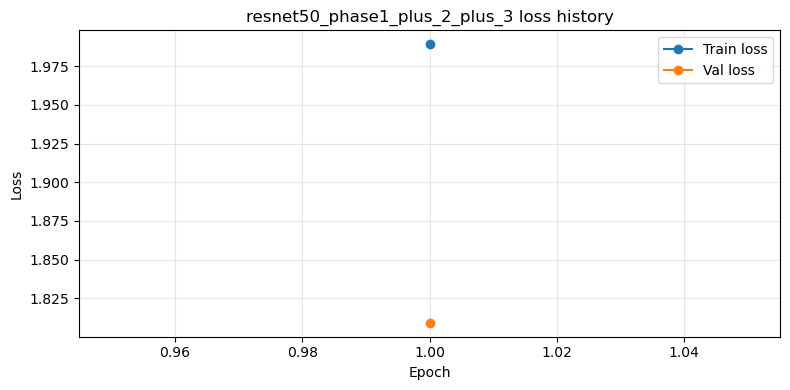

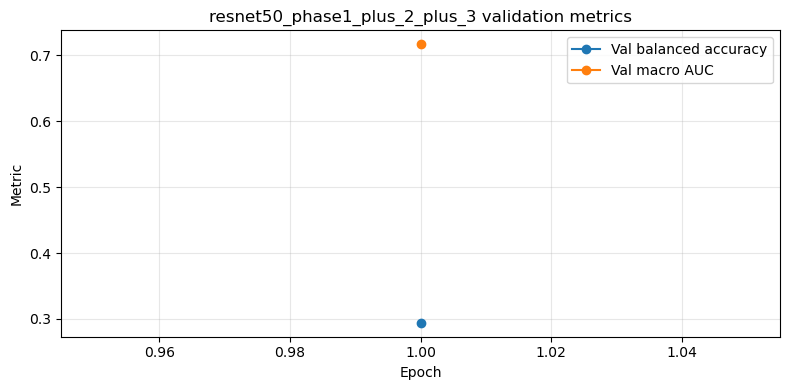

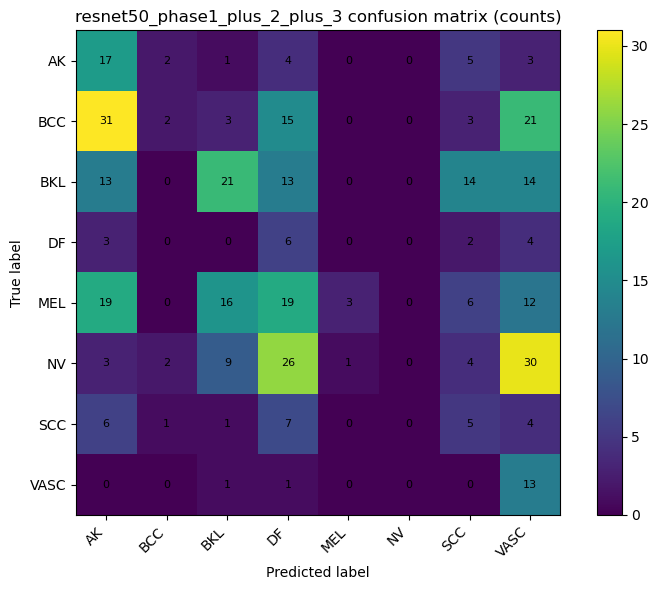

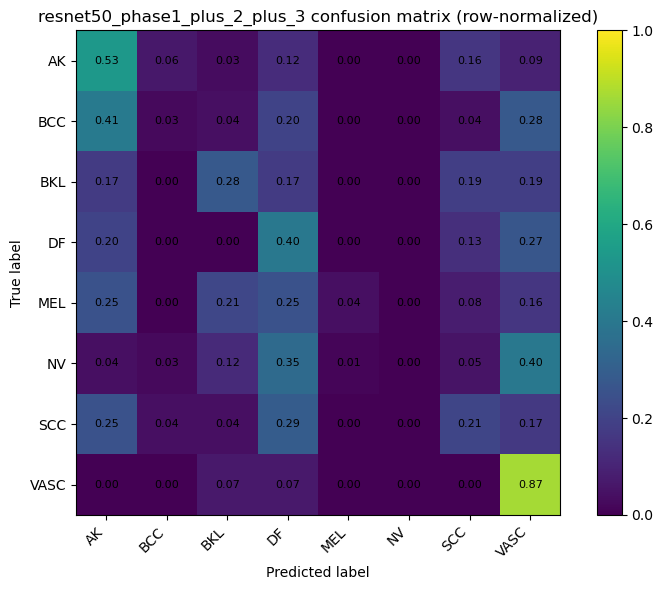

Running backbone=resnet50, stage=phase1_plus_2_plus_3_plus_4, epochs=1
Active phases: phase1 + phase2 + phase3 + phase4
Train size: 1239
Validation size: 386
Use CutMix: True
resnet50 | phase1_plus_2_plus_3_plus_4 | Epoch 01/01 | train_size=1239 | train_loss=1.9906 | val_loss=1.8153 | val_bal_acc=0.2461 | val_macro_auc=0.6831 | epoch_time=0.38 min


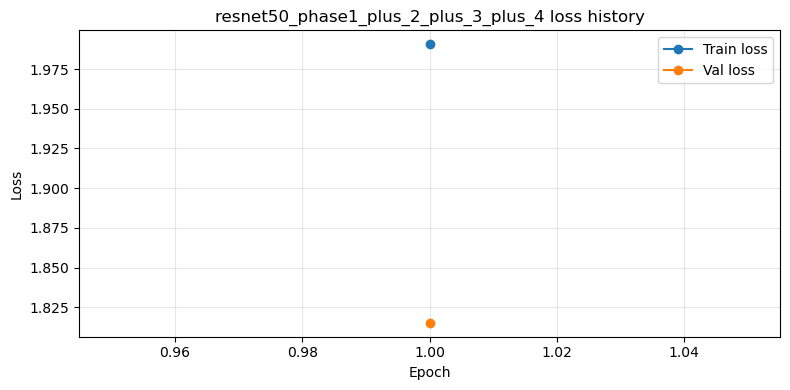

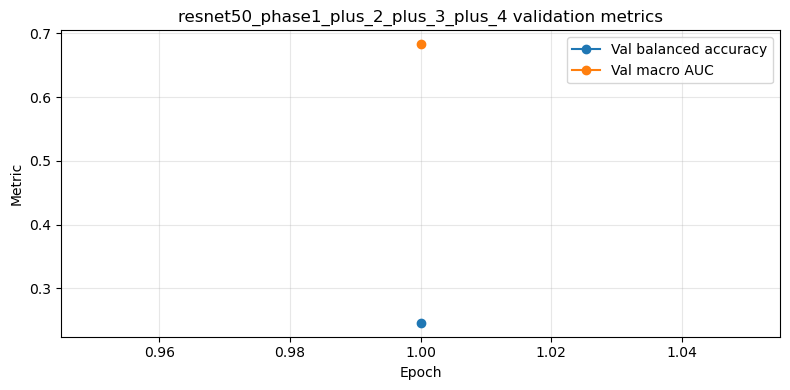

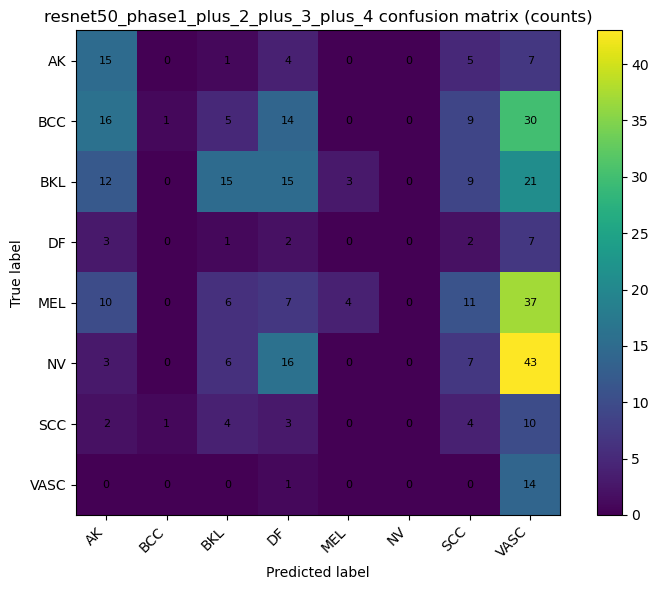

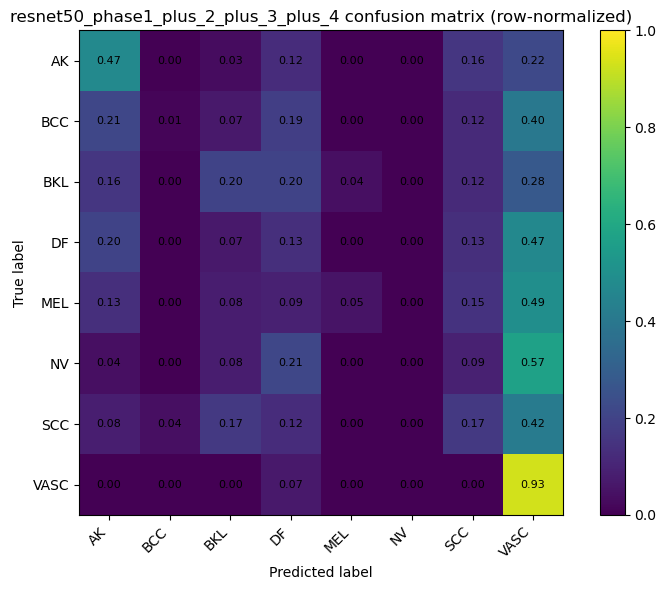

Running backbone=efficientnet_b0, stage=baseline, epochs=1
Active phases: phase1
Train size: 1239
Validation size: 386
Use CutMix: False
efficientnet_b0 | baseline | Epoch 01/01 | train_size=1239 | train_loss=1.9928 | val_loss=1.8452 | val_bal_acc=0.3257 | val_macro_auc=0.7445 | epoch_time=0.33 min


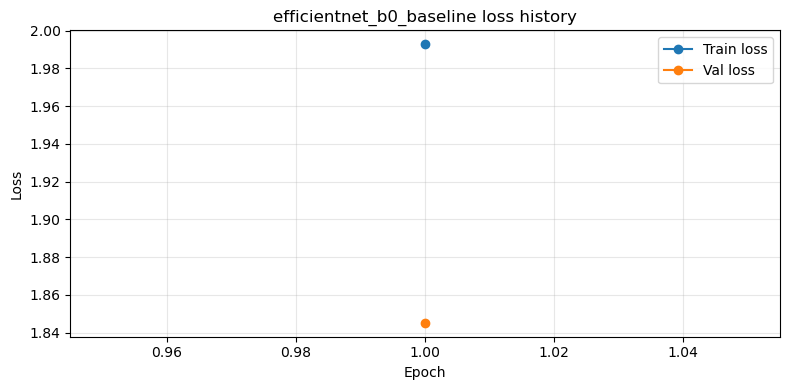

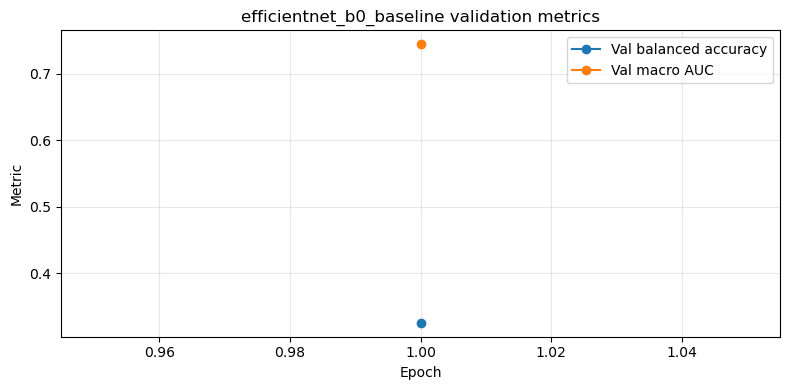

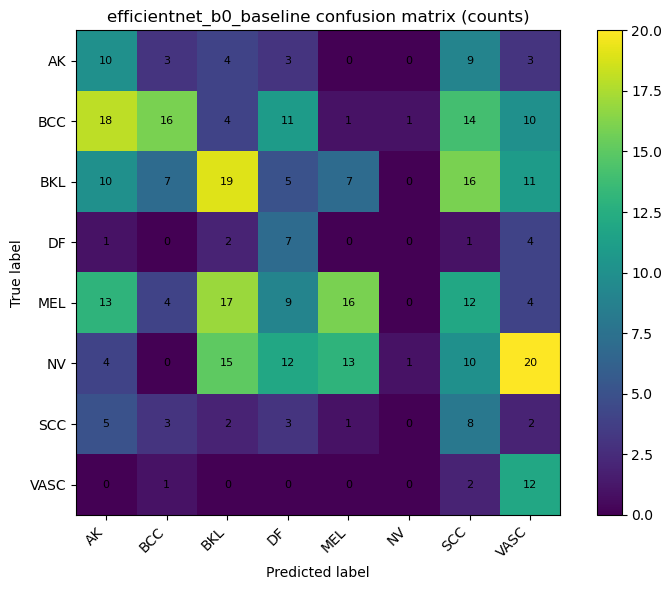

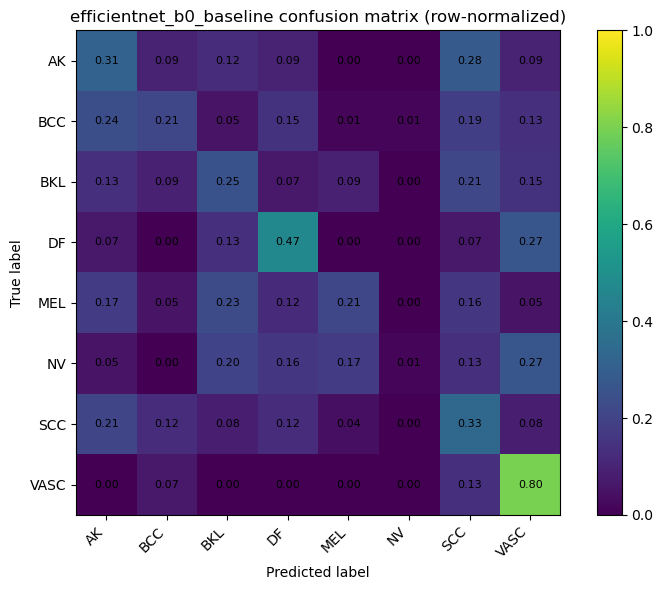

Running backbone=efficientnet_b0, stage=phase1_plus_2, epochs=1
Active phases: phase1 + phase2
Train size: 1239
Validation size: 386
Use CutMix: False
efficientnet_b0 | phase1_plus_2 | Epoch 01/01 | train_size=1239 | train_loss=2.0005 | val_loss=1.8212 | val_bal_acc=0.3085 | val_macro_auc=0.7250 | epoch_time=0.33 min


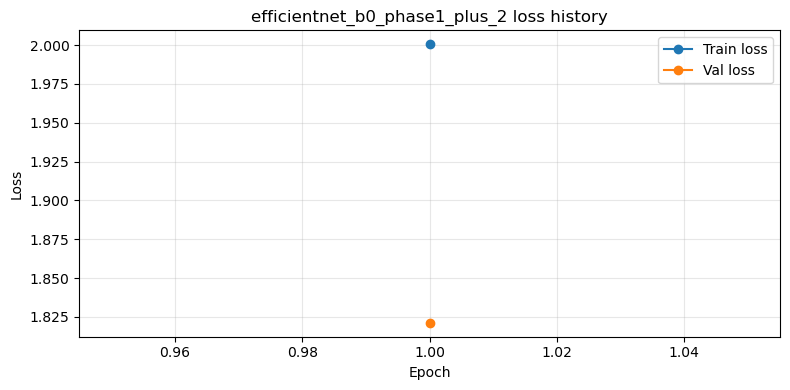

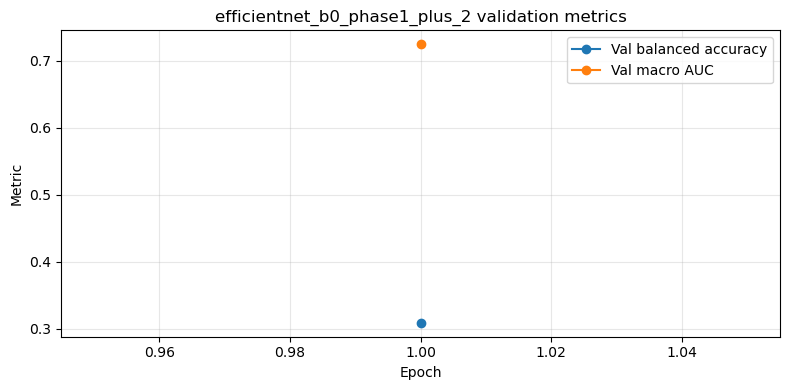

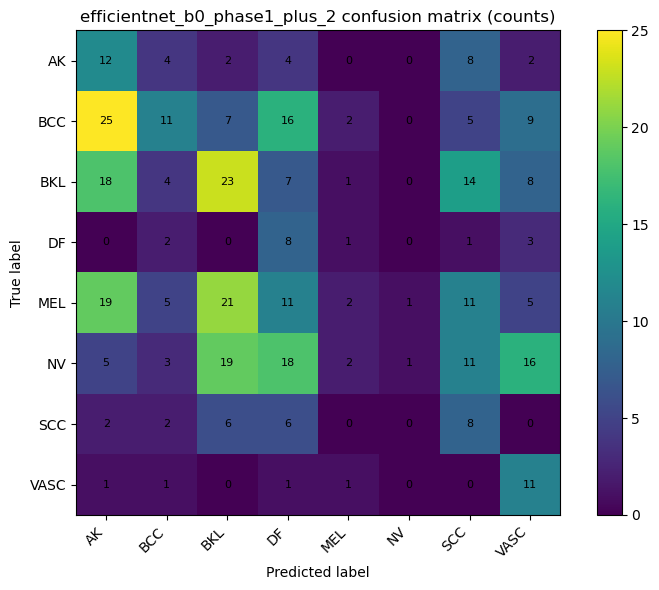

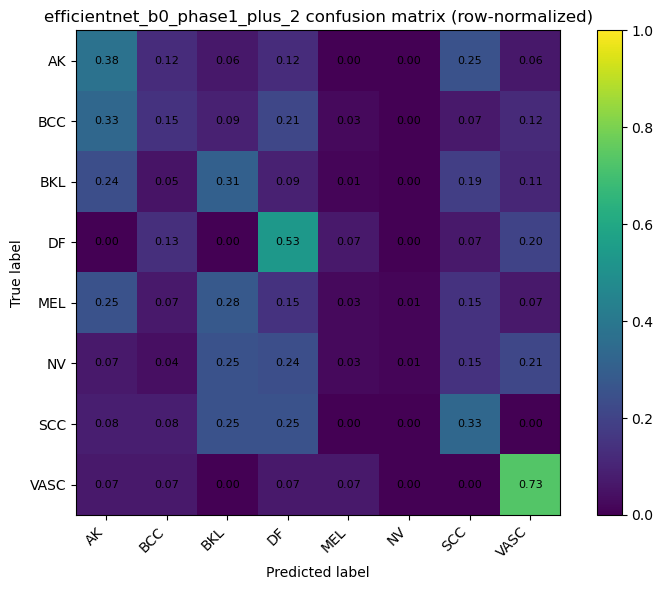

Running backbone=efficientnet_b0, stage=phase1_plus_2_plus_3, epochs=1
Active phases: phase1 + phase2 + phase3
Train size: 1239
Validation size: 386
Use CutMix: False
efficientnet_b0 | phase1_plus_2_plus_3 | Epoch 01/01 | train_size=1239 | train_loss=1.9731 | val_loss=1.7853 | val_bal_acc=0.3624 | val_macro_auc=0.7224 | epoch_time=0.35 min


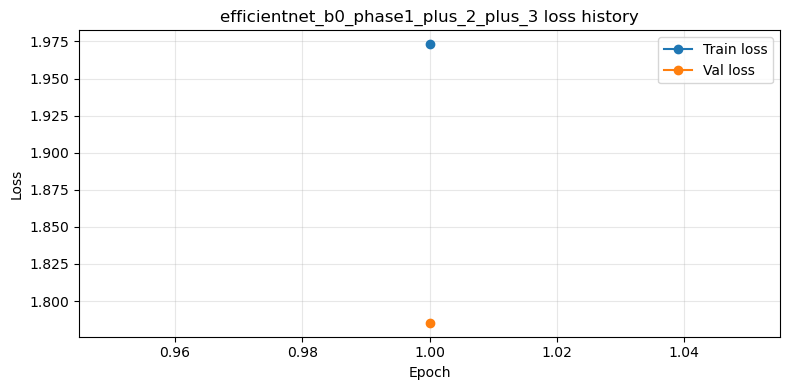

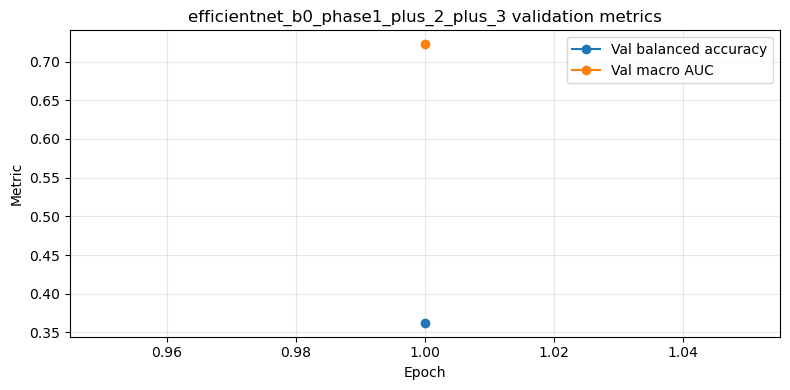

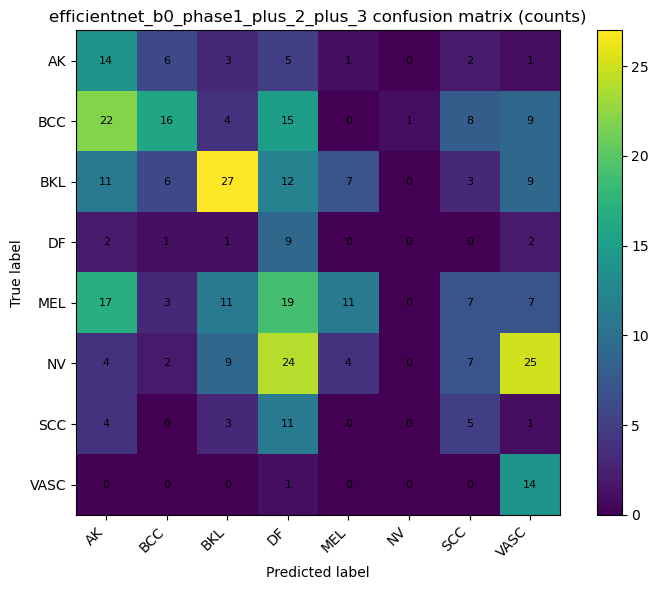

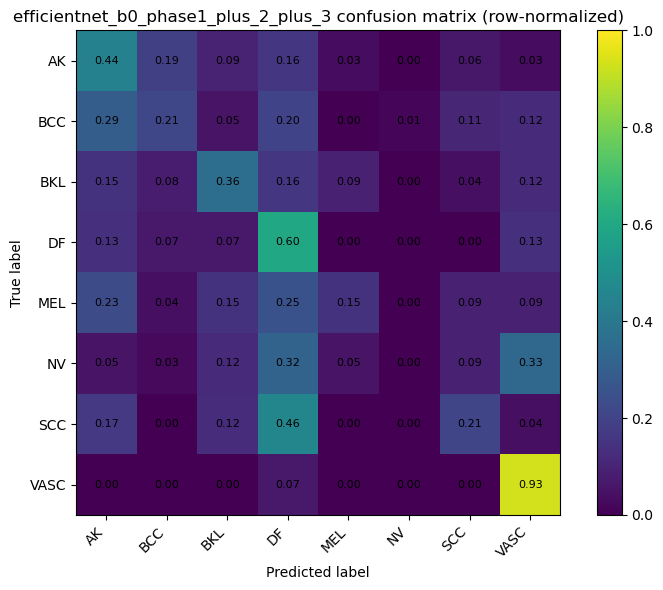

Running backbone=efficientnet_b0, stage=phase1_plus_2_plus_3_plus_4, epochs=1
Active phases: phase1 + phase2 + phase3 + phase4
Train size: 1239
Validation size: 386
Use CutMix: True
efficientnet_b0 | phase1_plus_2_plus_3_plus_4 | Epoch 01/01 | train_size=1239 | train_loss=2.0153 | val_loss=1.8475 | val_bal_acc=0.2832 | val_macro_auc=0.6897 | epoch_time=0.36 min


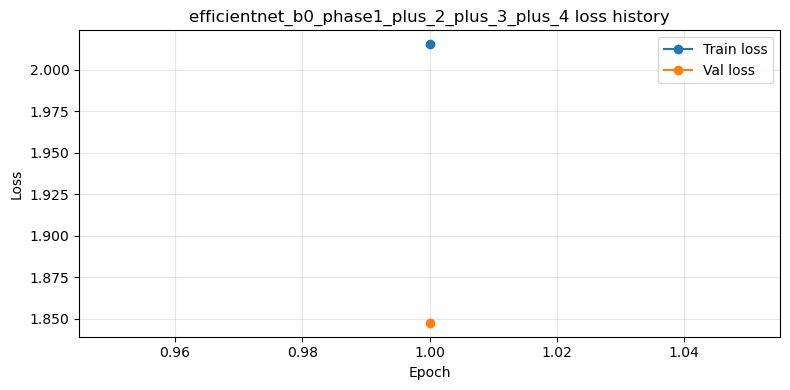

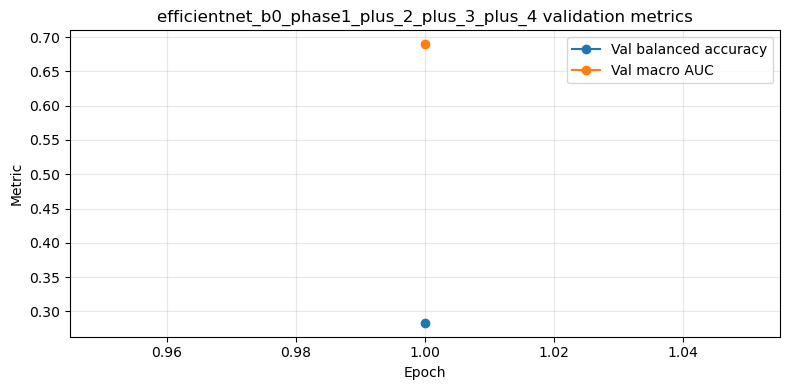

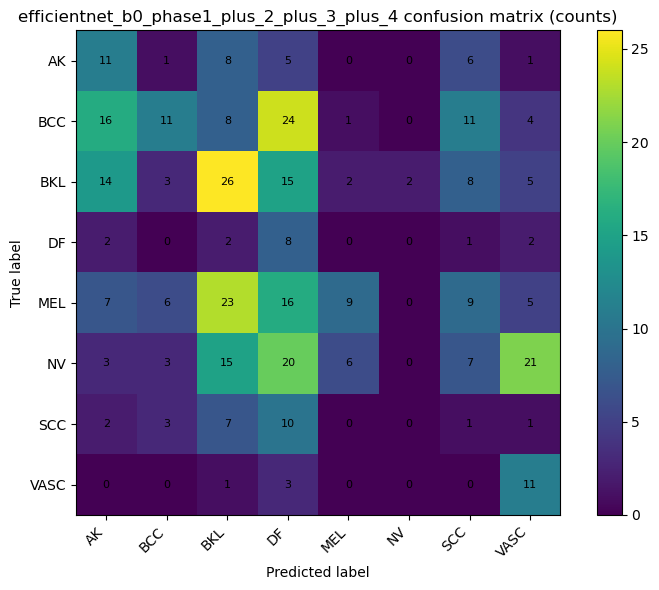

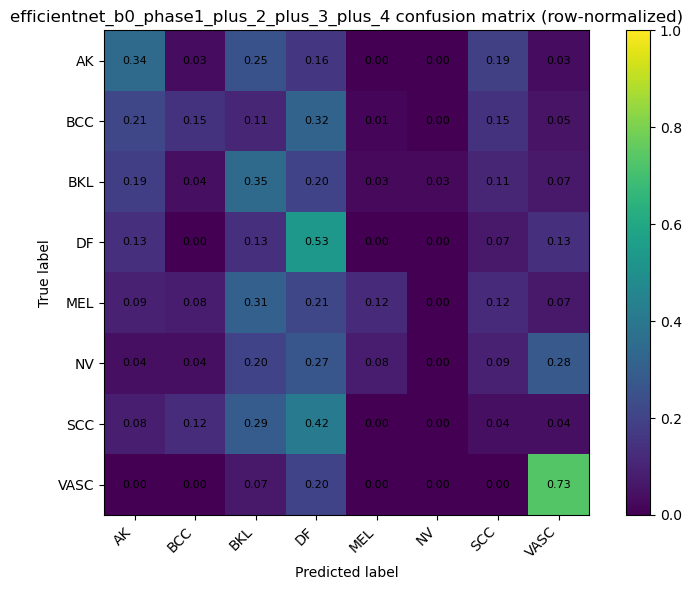

Running backbone=densenet121, stage=baseline, epochs=1
Active phases: phase1
Train size: 1239
Validation size: 386
Use CutMix: False
densenet121 | baseline | Epoch 01/01 | train_size=1239 | train_loss=1.7996 | val_loss=1.4422 | val_bal_acc=0.4199 | val_macro_auc=0.7928 | epoch_time=0.36 min


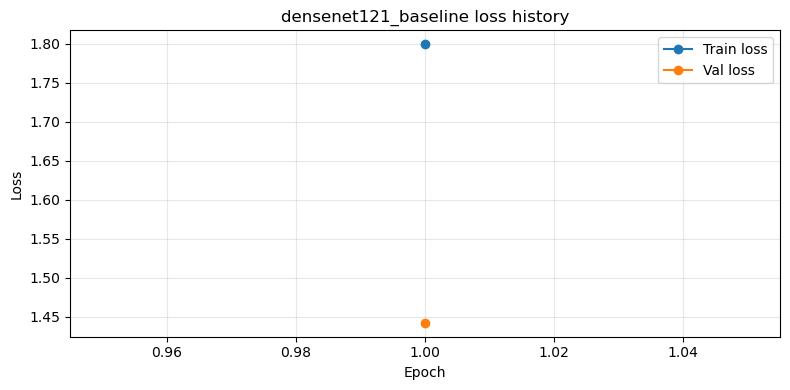

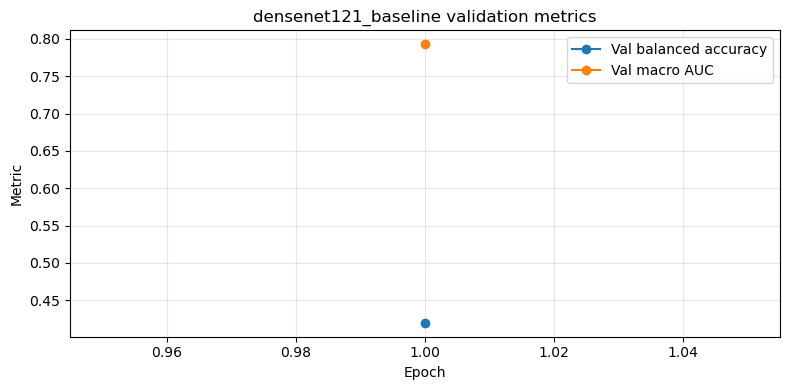

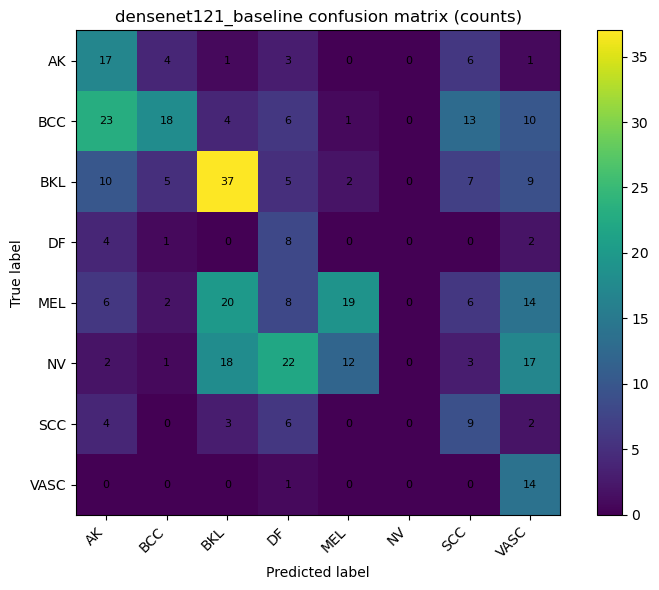

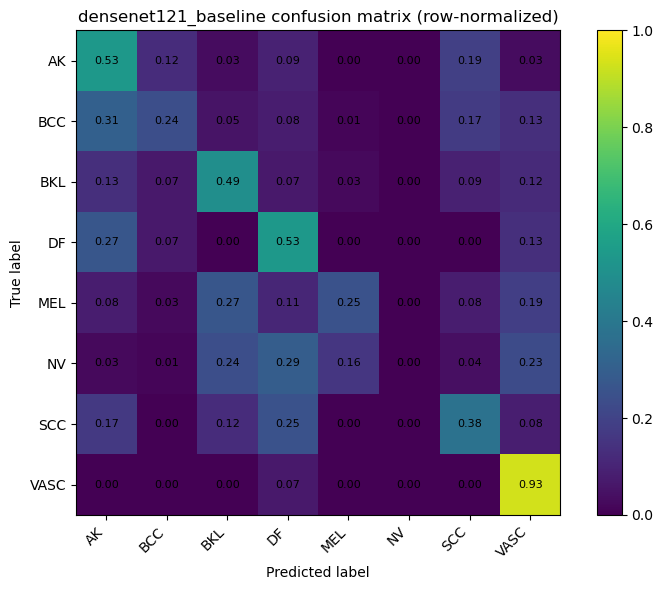

Running backbone=densenet121, stage=phase1_plus_2, epochs=1
Active phases: phase1 + phase2
Train size: 1239
Validation size: 386
Use CutMix: False
densenet121 | phase1_plus_2 | Epoch 01/01 | train_size=1239 | train_loss=1.8942 | val_loss=1.4850 | val_bal_acc=0.3521 | val_macro_auc=0.8061 | epoch_time=0.36 min


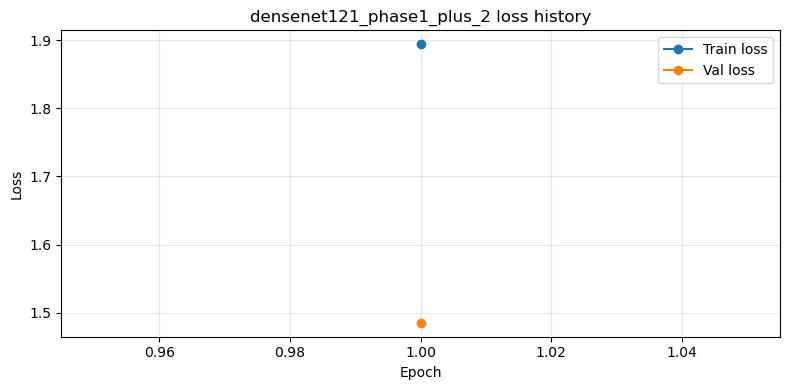

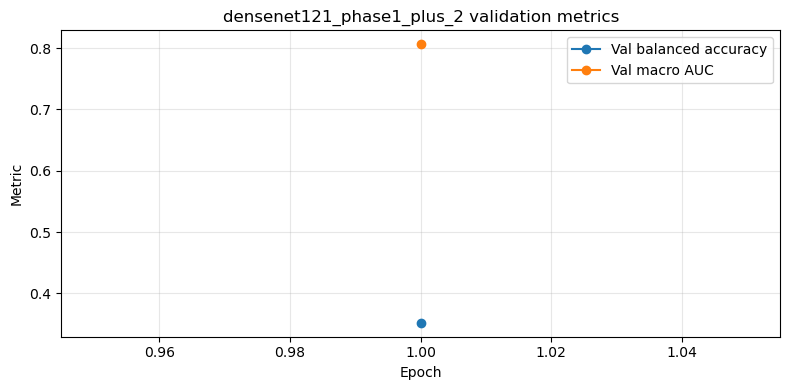

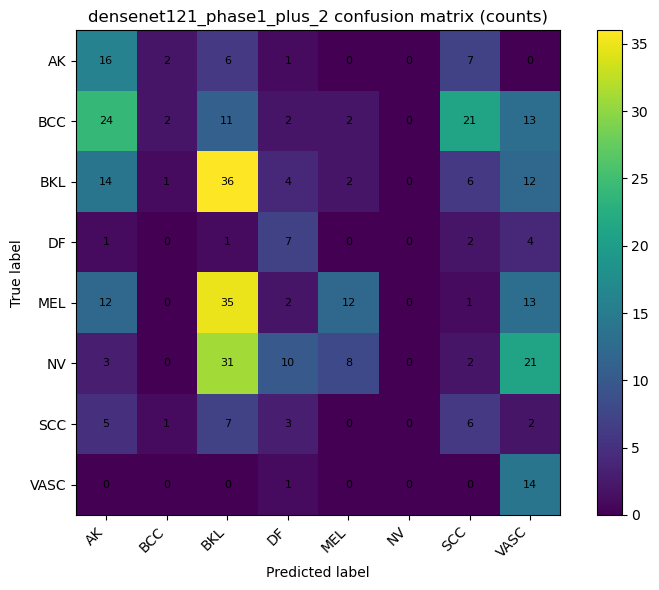

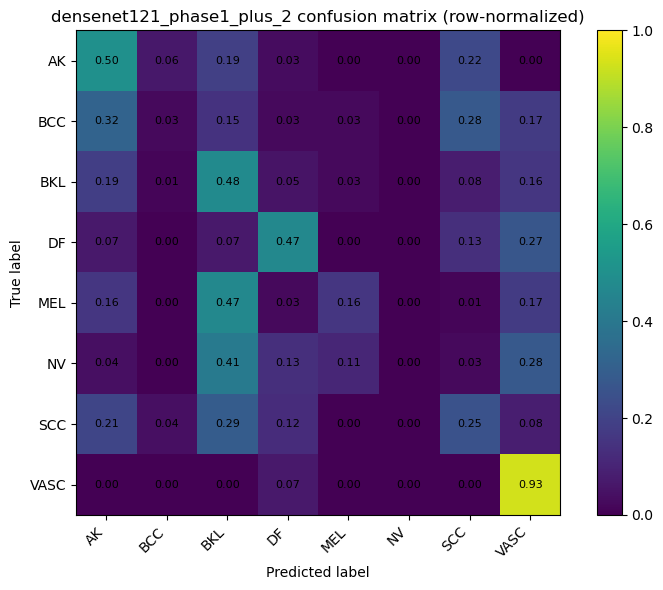

Running backbone=densenet121, stage=phase1_plus_2_plus_3, epochs=1
Active phases: phase1 + phase2 + phase3
Train size: 1239
Validation size: 386
Use CutMix: False
densenet121 | phase1_plus_2_plus_3 | Epoch 01/01 | train_size=1239 | train_loss=1.8793 | val_loss=1.5019 | val_bal_acc=0.3847 | val_macro_auc=0.8082 | epoch_time=0.38 min


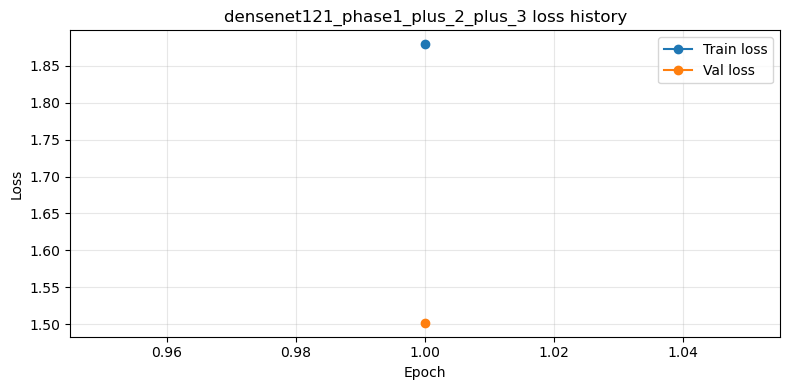

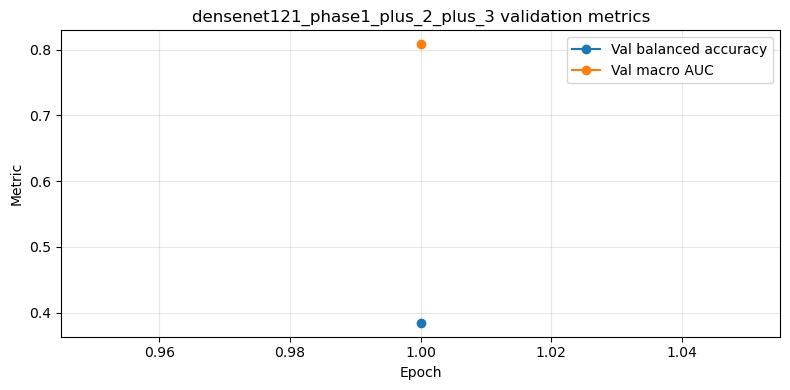

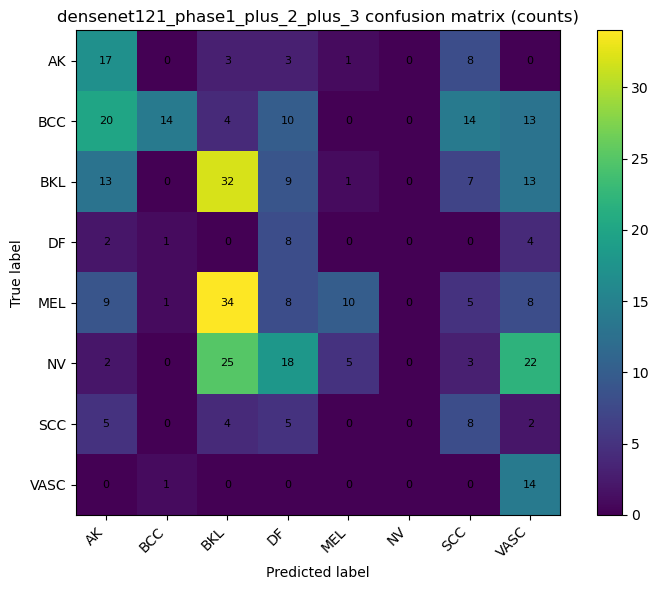

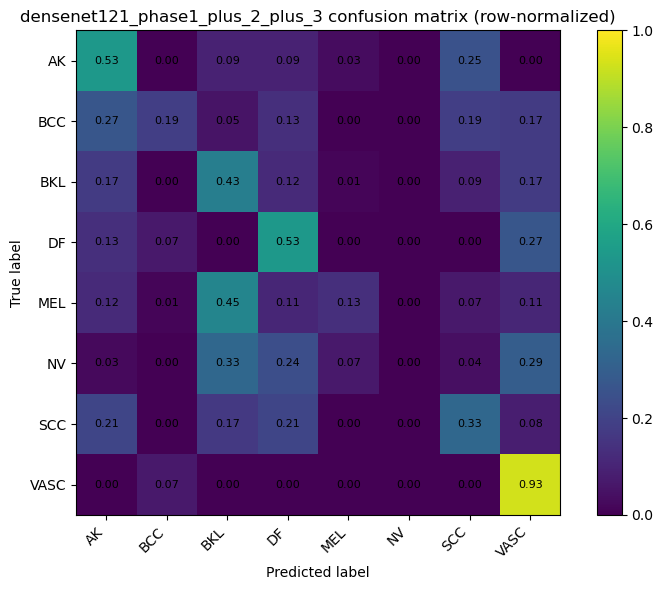

Running backbone=densenet121, stage=phase1_plus_2_plus_3_plus_4, epochs=1
Active phases: phase1 + phase2 + phase3 + phase4
Train size: 1239
Validation size: 386
Use CutMix: True
densenet121 | phase1_plus_2_plus_3_plus_4 | Epoch 01/01 | train_size=1239 | train_loss=1.8908 | val_loss=1.5377 | val_bal_acc=0.3794 | val_macro_auc=0.7706 | epoch_time=0.40 min


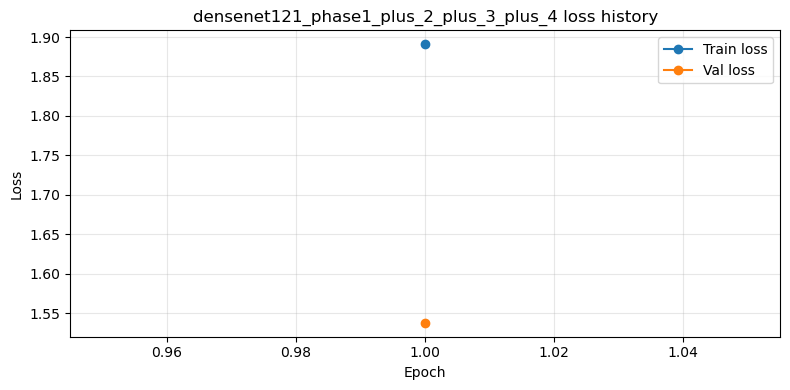

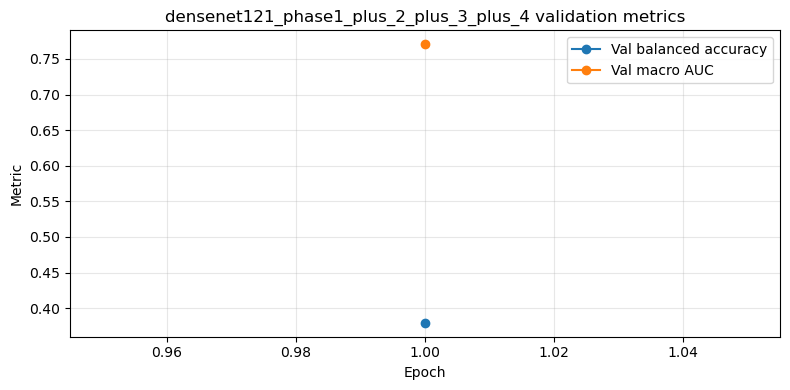

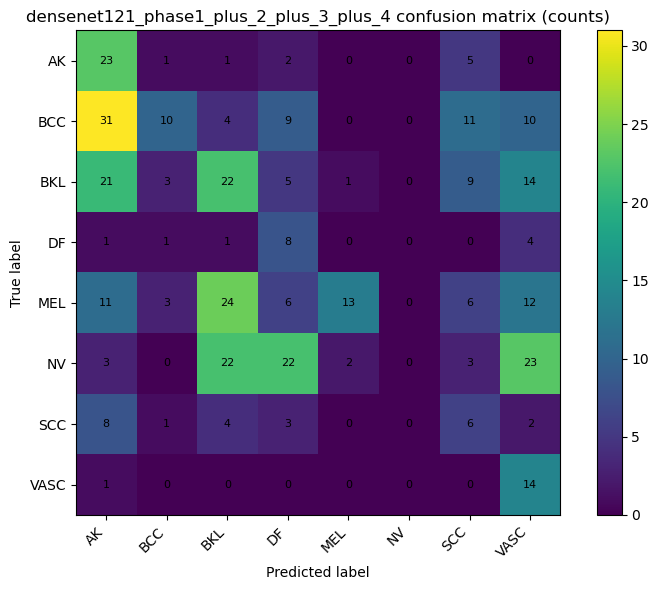

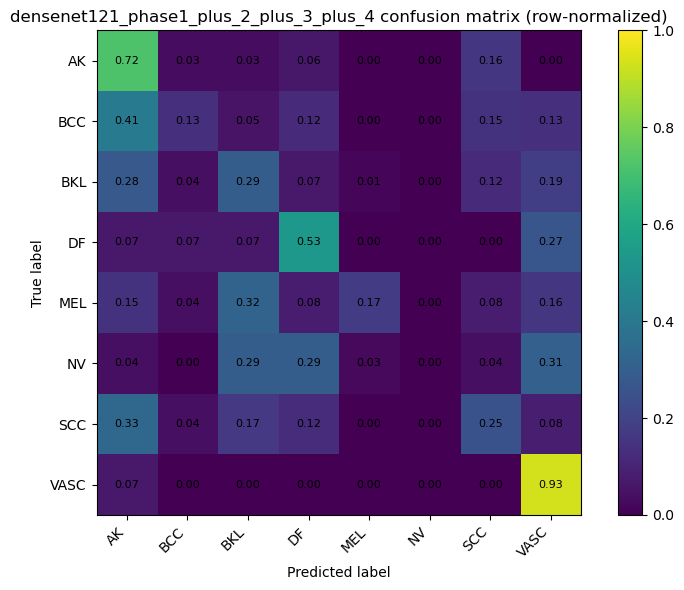

,backbone,stage,epochs_requested,train_size,combined_train_size,val_size,active_phases,augmentation_mode,use_cutmix,best_epoch,...,auc_BKL,auc_DF,auc_MEL,auc_NV,auc_SCC,auc_VASC,history_path,pred_path,report_path,checkpoint_path
0,resnet50,baseline,1,1239,1239,386,phase1,on_the_fly_cumulative_transform,False,1,...,0.699207,0.661635,0.744009,0.557385,0.662753,0.929380,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,resnet50,phase1_plus_2,1,1239,1239,386,phase1+phase2,on_the_fly_cumulative_transform,False,1,...,0.655091,0.782390,0.760986,0.574705,0.643186,0.944654,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,phase1_plus_2_plus_3,1,1239,1239,386,phase1+phase2+phase3,on_the_fly_cumulative_transform,False,1,...,0.720900,0.647619,0.737063,0.591125,0.605893,0.917700,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
3,resnet50,phase1_plus_2_plus_3_plus_4,1,1239,1239,386,phase1+phase2+phase3+phase4,on_the_fly_cumulative_transform,True,1,...,0.667910,0.529200,0.758285,0.468210,0.676335,0.955975,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
4,efficientnet_b0,baseline,1,1239,1239,386,phase1,on_the_fly_cumulative_transform,False,1,...,0.638885,0.739443,0.713526,0.731618,0.674378,0.932794,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
5,efficientnet_b0,phase1_plus_2,1,1239,1239,386,phase1+phase2,on_the_fly_cumulative_transform,False,1,...,0.644587,0.808625,0.583494,0.687846,0.721915,0.921833,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
6,efficientnet_b0,phase1_plus_2_plus_3,1,1239,1239,386,phase1+phase2+phase3,on_the_fly_cumulative_transform,False,1,...,0.682487,0.826774,0.740922,0.526045,0.612224,0.955436,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
7,efficientnet_b0,phase1_plus_2_plus_3_plus_4,1,1239,1239,386,phase1+phase2+phase3+phase4,on_the_fly_cumulative_transform,True,1,...,0.664266,0.773585,0.699507,0.595884,0.527049,0.932794,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
8,densenet121,baseline,1,1239,1239,386,phase1,on_the_fly_cumulative_transform,False,1,...,0.747267,0.732615,0.801672,0.742294,0.719153,0.945193,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
9,densenet121,phase1_plus_2,1,1239,1239,386,phase1+phase2,on_the_fly_cumulative_transform,False,1,...,0.675798,0.822462,0.791983,0.831511,0.771639,0.958311,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


Saved results to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_smoke_comparison.csv


In [18]:
comparison_rows = []

for backbone in BACKBONES:
    for stage_name in ABLATION_STAGES:
        result = run_ablation_experiment(
            backbone=backbone,
            stage_name=stage_name,
        )
        comparison_rows.append(result)

results_df = pd.DataFrame(comparison_rows)
display(results_df)

results_out = METRIC_DIR / (
    "ablation_smoke_comparison.csv" if SMOKE_MODE else "ablation_full_comparison.csv"
)
results_df.to_csv(results_out, index=False)

print("Saved results to:", results_out)

## Smoke-test backbone-wise comparison plots

These plots summarize the smoke-mode cumulative ablation results for each backbone separately.

Their purpose is diagnostic rather than final. They help confirm that the cumulative stage ordering, metric tracking, and plotting pipeline are all working before launching the full-data runs.

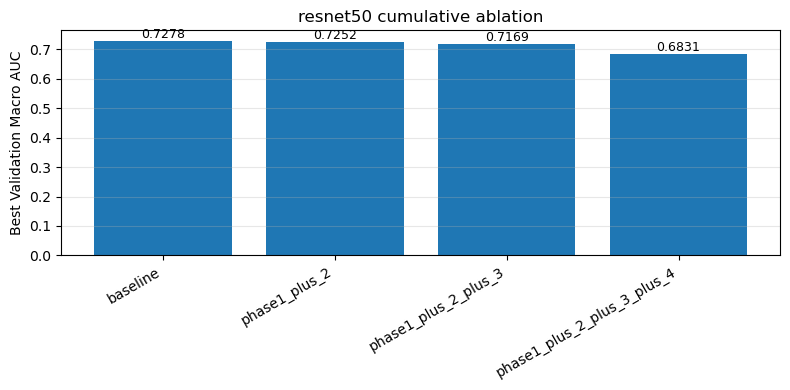

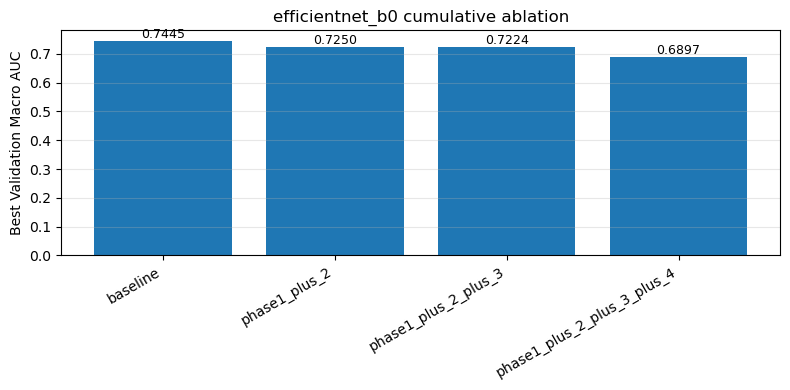

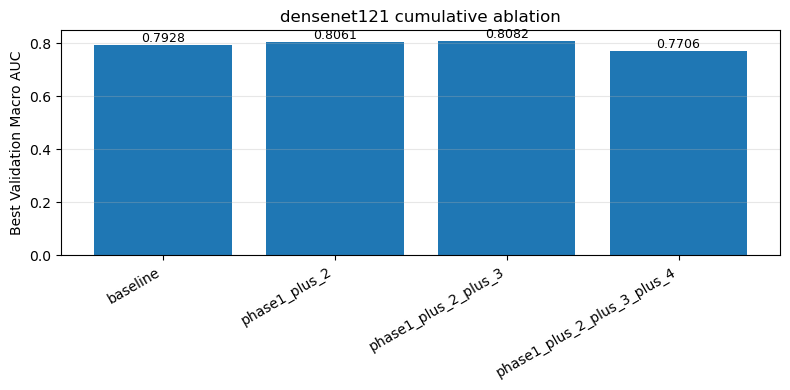

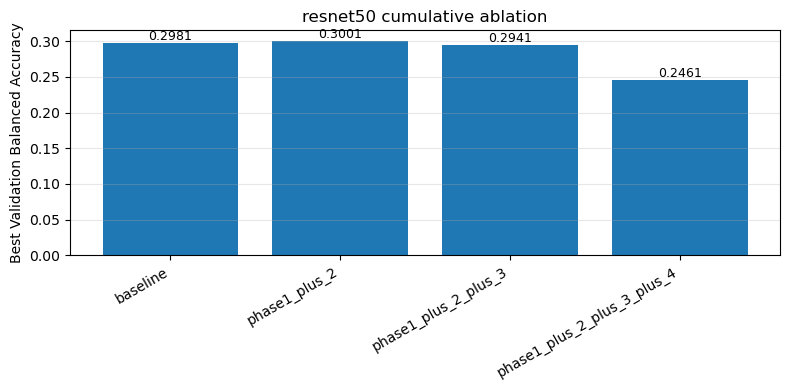

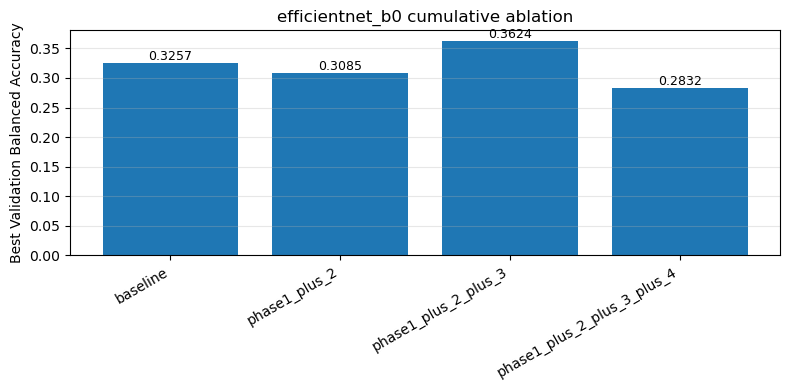

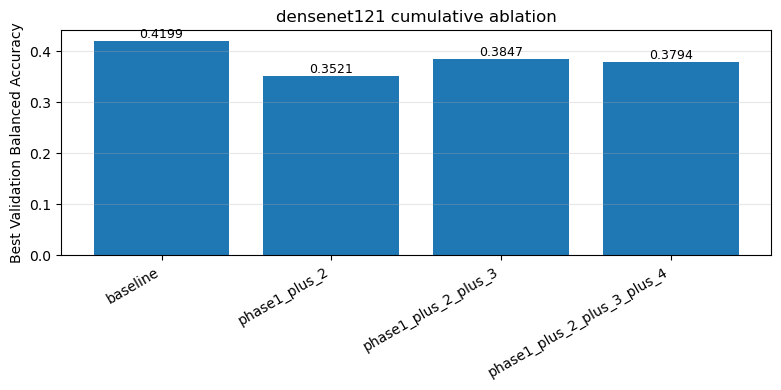

In [19]:
if results_df.empty:
    print("results_df is empty. Run the smoke cumulative ablation block first.")
else:
    for metric_col, metric_label in [
        ("best_val_macro_auc", "Best Validation Macro AUC"),
        ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
    ]:
        for backbone in BACKBONES:
            subset = results_df[results_df["backbone"] == backbone].copy()
            if subset.empty:
                continue

            subset["stage"] = pd.Categorical(
                subset["stage"],
                categories=ABLATION_STAGES,
                ordered=True,
            )
            subset = subset.sort_values("stage")

            plt.figure(figsize=(8, 4))
            bars = plt.bar(subset["stage"].astype(str), subset[metric_col])
            plt.ylabel(metric_label)
            plt.title(f"{backbone} cumulative ablation")
            plt.xticks(rotation=30, ha="right")
            plt.grid(axis="y", alpha=0.3)

            for bar, value in zip(bars, subset[metric_col]):
                if pd.notna(value):
                    plt.text(
                        bar.get_x() + bar.get_width() / 2,
                        value,
                        f"{value:.4f}",
                        ha="center",
                        va="bottom",
                        fontsize=9,
                    )

            plt.tight_layout()
            out_name = f"{backbone}_{metric_col}_ablation.png"
            plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
            plt.show()

## Smoke-test cross-backbone summary plots

These plots compare cumulative ablation trends across backbones using smoke-mode results.

They are mainly intended to verify that the cross-backbone aggregation and plotting logic work correctly before the full-data backbone-specific runs are launched.

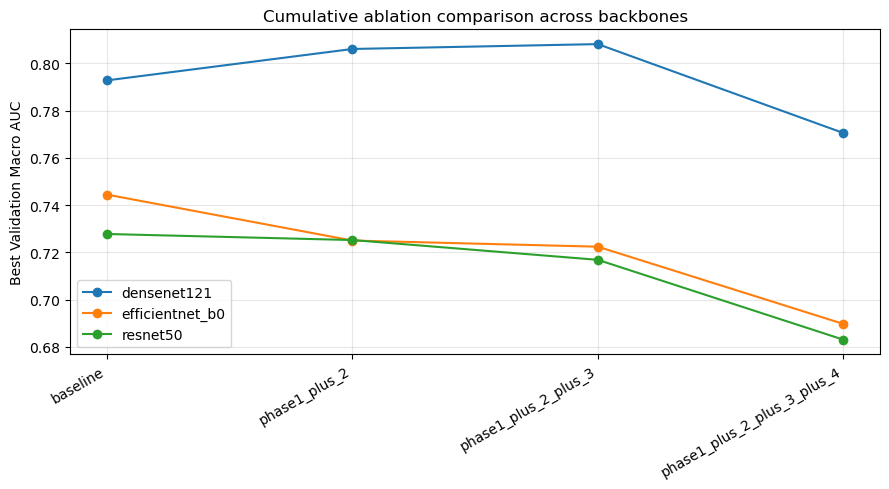

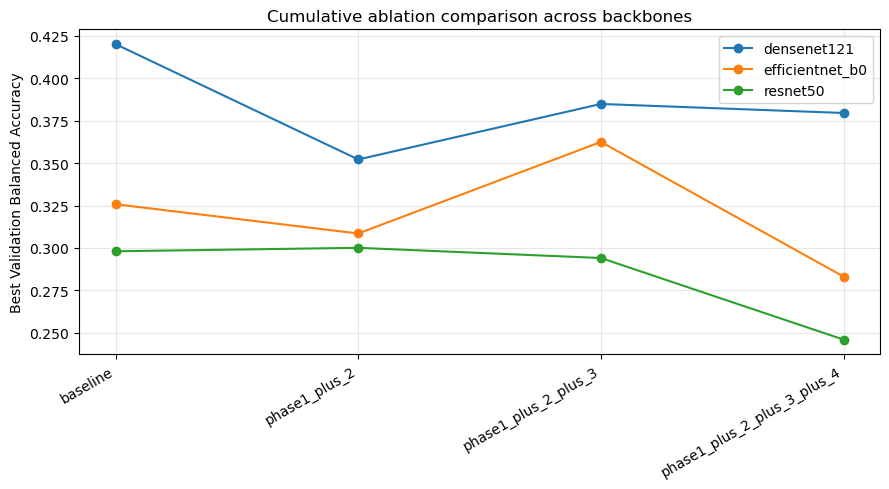

In [20]:
if results_df.empty:
    print("results_df is empty. Run the smoke cumulative ablation block first.")
else:
    for metric_col, metric_label in [
        ("best_val_macro_auc", "Best Validation Macro AUC"),
        ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
    ]:
        pivot_df = results_df.pivot(
            index="stage",
            columns="backbone",
            values=metric_col,
        ).reindex(ABLATION_STAGES)

        plt.figure(figsize=(9, 5))
        for backbone in pivot_df.columns:
            plt.plot(pivot_df.index, pivot_df[backbone], marker="o", label=backbone)

        plt.ylabel(metric_label)
        plt.title("Cumulative ablation comparison across backbones")
        plt.xticks(rotation=30, ha="right")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()

        out_name = f"cross_backbone_{metric_col}_ablation.png"
        plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
        plt.show()

## Smoke-test best-stage summary by backbone

This table identifies the best-performing cumulative stage for each backbone under smoke-mode execution.

The purpose is to verify that the result-ranking and summary-export logic work correctly before the full-data runs are carried out.

In [21]:
if results_df.empty:
    print("results_df is empty. No best-stage summary to compute.")
    best_by_auc = pd.DataFrame()
else:
    best_by_auc = (
        results_df.sort_values(
            by=["best_val_macro_auc", "best_val_balanced_accuracy"],
            ascending=False,
        )
        .groupby("backbone", as_index=False)
        .first()
    )

display(best_by_auc)

best_by_auc_out = METRIC_DIR / (
    "ablation_best_stage_by_backbone_smoke.csv"
    if SMOKE_MODE else
    "ablation_best_stage_by_backbone_full.csv"
)
best_by_auc.to_csv(best_by_auc_out, index=False)

print("Saved best-stage summary to:", best_by_auc_out)

,backbone,stage,epochs_requested,train_size,combined_train_size,val_size,active_phases,augmentation_mode,use_cutmix,best_epoch,...,auc_BKL,auc_DF,auc_MEL,auc_NV,auc_SCC,auc_VASC,history_path,pred_path,report_path,checkpoint_path
0,densenet121,phase1_plus_2_plus_3,1,1239,1239,386,phase1+phase2+phase3,on_the_fly_cumulative_transform,False,1,...,0.696249,0.766217,0.794169,0.811961,0.750691,0.964780,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,efficientnet_b0,baseline,1,1239,1239,386,phase1,on_the_fly_cumulative_transform,False,1,...,0.638885,0.739443,0.713526,0.731618,0.674378,0.932794,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,baseline,1,1239,1239,386,phase1,on_the_fly_cumulative_transform,False,1,...,0.699207,0.661635,0.744009,0.557385,0.662753,0.929380,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


Saved best-stage summary to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_best_stage_by_backbone_smoke.csv


## Full-data cumulative ablation execution

The full-data cumulative ablation study can now be executed at two levels of granularity:

- **Backbone-level cells**, which run one CNN across all four cumulative phases for a chosen number of epochs
- **Phase-level cells**, which run one specific `(backbone, phase)` combination for a chosen number of epochs

The backbone-level cells are the default path for normal HPC usage.

The phase-level cells are included as future-proofing in case shorter HPC windows or interrupted jobs make finer-grained execution more practical.

In [22]:
# ==========================================
# CLEAR PRIOR IN-MEMORY RESULTS
# ==========================================

comparison_rows = []
results_df = pd.DataFrame()

print("Cleared prior in-memory comparison objects.")

Cleared prior in-memory comparison objects.


In [23]:
# =========================
# FULL-RUN OVERRIDE CONTROL
# =========================

RUN_FULL_EXPERIMENT = True
FULL_RUN_EPOCHS = 5

if RUN_FULL_EXPERIMENT:
    SMOKE_MODE = False
    EPOCHS = FULL_RUN_EPOCHS

    train_run_df = train_df.copy()
    val_run_df = val_df.copy()

    print("Full experiment override is ON")
    print("SMOKE_MODE:", SMOKE_MODE)
    print("EPOCHS:", EPOCHS)
    print("train_run_df shape:", train_run_df.shape)
    print("val_run_df shape:", val_run_df.shape)
else:
    print("RUN_FULL_EXPERIMENT is False. No override applied.")

Full experiment override is ON
SMOKE_MODE: False
EPOCHS: 5
train_run_df shape: (21531, 22)
val_run_df shape: (3800, 22)


In [24]:
# ==========================================
# RESAVE CONFIG SO OUTPUTS MATCH THIS RUN
# ==========================================

EXPERIMENT_CONFIG = {
    "notebook": "04_ablation_study",
    "seed": EXPERIMENT_SEED,
    "smoke_mode": SMOKE_MODE,
    "ablation_stages": ABLATION_STAGES,
    "backbones": BACKBONES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "freeze_features": FREEZE_FEATURES,
    "save_checkpoints": SAVE_CHECKPOINTS,
    "num_workers": NUM_WORKERS,
    "run_full_experiment": RUN_FULL_EXPERIMENT,
    "augmentation_mode": "on_the_fly_cumulative_transform",
    "dataset_expansion": False,
    "full_run_epochs": FULL_RUN_EPOCHS if RUN_FULL_EXPERIMENT else None,
    "train_rows": int(len(train_run_df)),
    "val_rows": int(len(val_run_df)),
}

config_path = CONFIG_DIR / ("smoke_config.json" if SMOKE_MODE else "full_config.json")

with open(config_path, "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)

print("Updated config saved to:", config_path)
print(json.dumps(EXPERIMENT_CONFIG, indent=2))

Updated config saved to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/configs/04_ablation_study/full_config.json
{
  "notebook": "04_ablation_study",
  "seed": 42,
  "smoke_mode": false,
  "ablation_stages": [
    "baseline",
    "phase1_plus_2",
    "phase1_plus_2_plus_3",
    "phase1_plus_2_plus_3_plus_4"
  ],
  "backbones": [
    "resnet50",
    "efficientnet_b0",
    "densenet121"
  ],
  "image_size": 224,
  "batch_size": 32,
  "epochs": 5,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "freeze_features": false,
  "save_checkpoints": true,
  "num_workers": 0,
  "run_full_experiment": true,
  "augmentation_mode": "on_the_fly_cumulative_transform",
  "dataset_expansion": false,
  "full_run_epochs": 5,
  "train_rows": 21531,
  "val_rows": 3800
}


Running backbone=resnet50, stage=baseline, epochs=5
Active phases: phase1
Train size: 21531
Validation size: 3800
Use CutMix: False
resnet50 | baseline | Epoch 01/05 | train_size=21531 | train_loss=1.3015 | val_loss=1.0327 | val_bal_acc=0.6522 | val_macro_auc=0.9301 | epoch_time=5.55 min
resnet50 | baseline | Epoch 02/05 | train_size=21531 | train_loss=0.7623 | val_loss=0.8254 | val_bal_acc=0.7072 | val_macro_auc=0.9504 | epoch_time=5.50 min
resnet50 | baseline | Epoch 03/05 | train_size=21531 | train_loss=0.4821 | val_loss=0.8114 | val_bal_acc=0.7160 | val_macro_auc=0.9528 | epoch_time=5.48 min
resnet50 | baseline | Epoch 04/05 | train_size=21531 | train_loss=0.3382 | val_loss=0.8155 | val_bal_acc=0.7590 | val_macro_auc=0.9545 | epoch_time=5.53 min
resnet50 | baseline | Epoch 05/05 | train_size=21531 | train_loss=0.2622 | val_loss=1.0680 | val_bal_acc=0.7016 | val_macro_auc=0.9559 | epoch_time=5.44 min


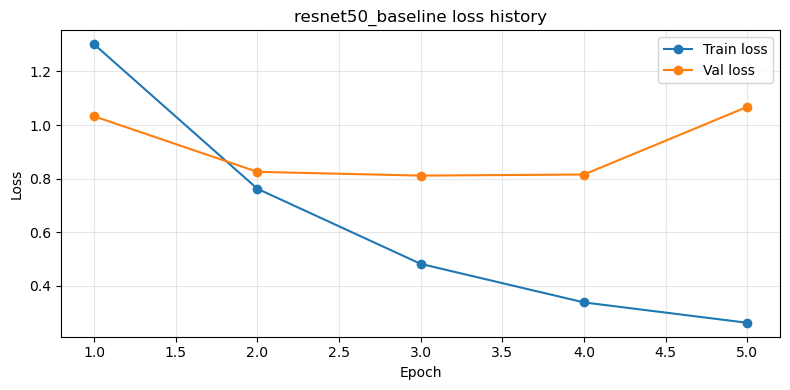

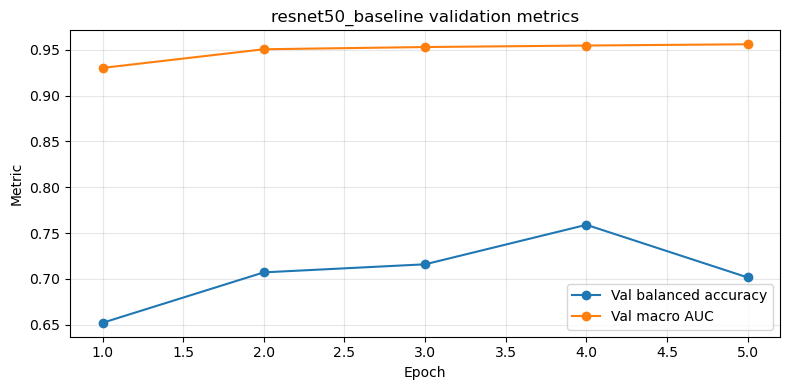

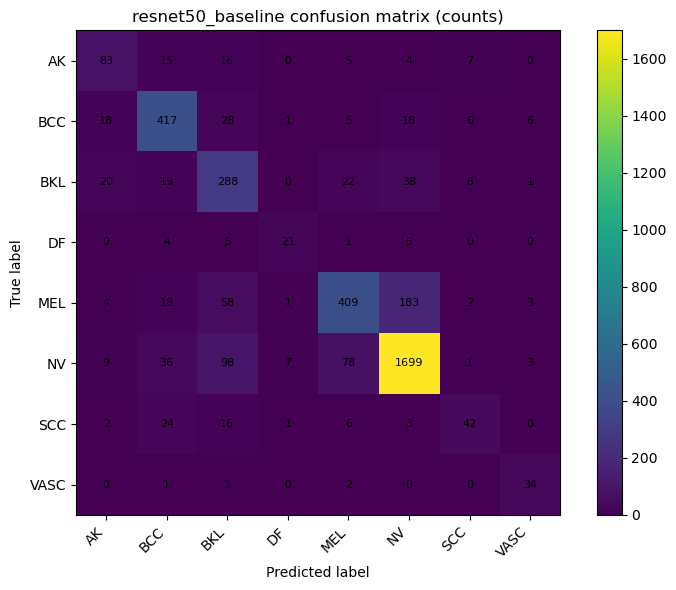

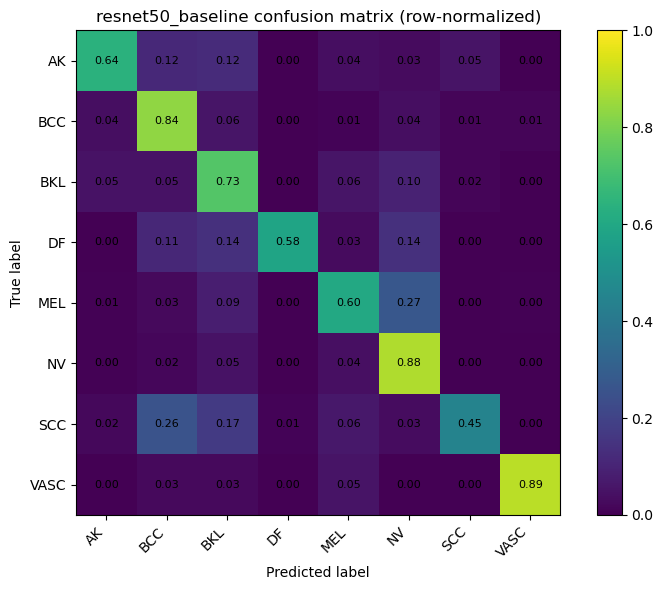

In [25]:
resnet50_phase1_result = run_ablation_experiment(
    backbone="resnet50",
    stage_name="baseline",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=resnet50, stage=phase1_plus_2, epochs=5
Active phases: phase1 + phase2
Train size: 21531
Validation size: 3800
Use CutMix: False
resnet50 | phase1_plus_2 | Epoch 01/05 | train_size=21531 | train_loss=1.3113 | val_loss=0.9865 | val_bal_acc=0.6425 | val_macro_auc=0.9285 | epoch_time=5.68 min
resnet50 | phase1_plus_2 | Epoch 02/05 | train_size=21531 | train_loss=0.9115 | val_loss=0.9377 | val_bal_acc=0.6706 | val_macro_auc=0.9373 | epoch_time=5.60 min
resnet50 | phase1_plus_2 | Epoch 03/05 | train_size=21531 | train_loss=0.7584 | val_loss=0.8421 | val_bal_acc=0.7176 | val_macro_auc=0.9495 | epoch_time=5.59 min
resnet50 | phase1_plus_2 | Epoch 04/05 | train_size=21531 | train_loss=0.6172 | val_loss=0.6817 | val_bal_acc=0.7611 | val_macro_auc=0.9590 | epoch_time=5.52 min
resnet50 | phase1_plus_2 | Epoch 05/05 | train_size=21531 | train_loss=0.5343 | val_loss=0.7254 | val_bal_acc=0.7476 | val_macro_auc=0.9593 | epoch_time=5.51 min


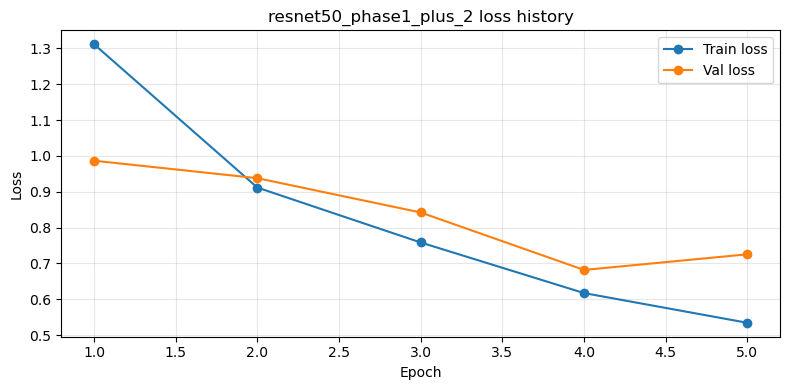

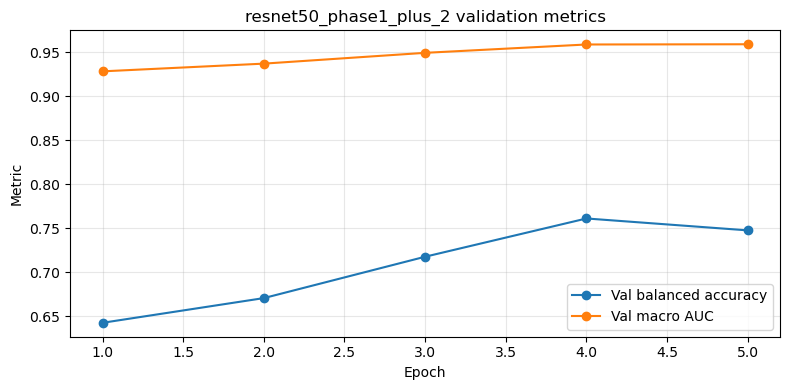

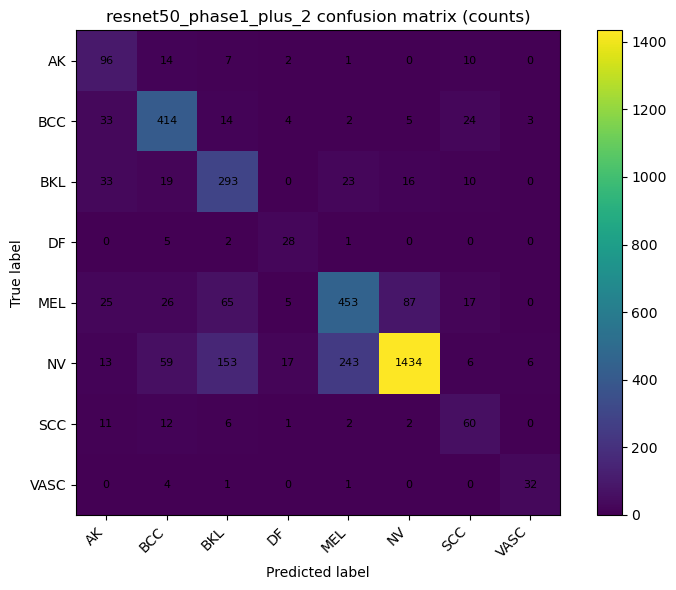

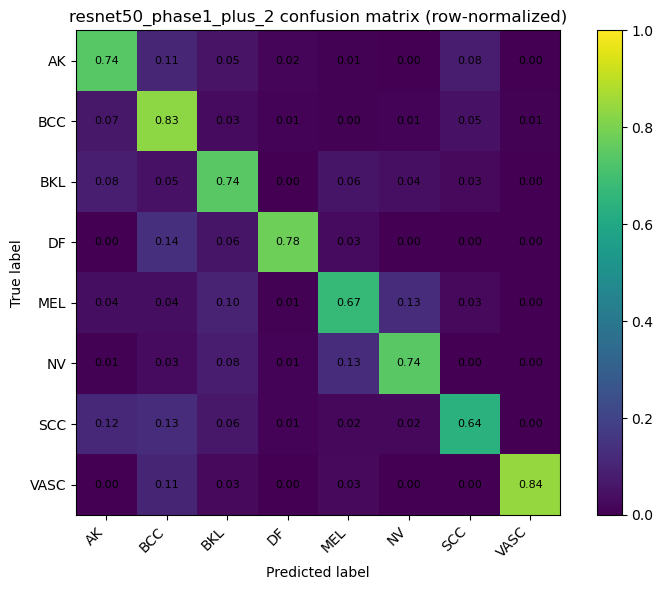

In [26]:
resnet50_phase12_result = run_ablation_experiment(
    backbone="resnet50",
    stage_name="phase1_plus_2",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=resnet50, stage=phase1_plus_2_plus_3, epochs=5
Active phases: phase1 + phase2 + phase3
Train size: 21531
Validation size: 3800
Use CutMix: False
resnet50 | phase1_plus_2_plus_3 | Epoch 01/05 | train_size=21531 | train_loss=1.3811 | val_loss=1.2574 | val_bal_acc=0.5931 | val_macro_auc=0.9001 | epoch_time=5.83 min
resnet50 | phase1_plus_2_plus_3 | Epoch 02/05 | train_size=21531 | train_loss=0.9807 | val_loss=0.9834 | val_bal_acc=0.6575 | val_macro_auc=0.9327 | epoch_time=5.89 min
resnet50 | phase1_plus_2_plus_3 | Epoch 03/05 | train_size=21531 | train_loss=0.8274 | val_loss=0.8398 | val_bal_acc=0.6780 | val_macro_auc=0.9504 | epoch_time=5.97 min
resnet50 | phase1_plus_2_plus_3 | Epoch 04/05 | train_size=21531 | train_loss=0.7488 | val_loss=0.8133 | val_bal_acc=0.7313 | val_macro_auc=0.9451 | epoch_time=5.79 min
resnet50 | phase1_plus_2_plus_3 | Epoch 05/05 | train_size=21531 | train_loss=0.6459 | val_loss=0.7595 | val_bal_acc=0.7321 | val_macro_auc=0.9546 | epoch_time=5.

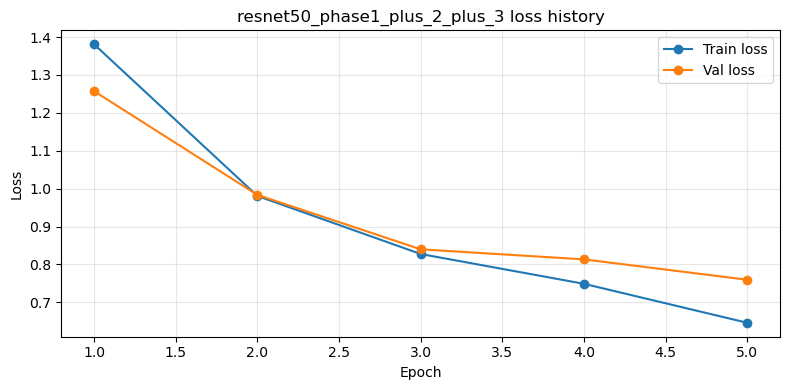

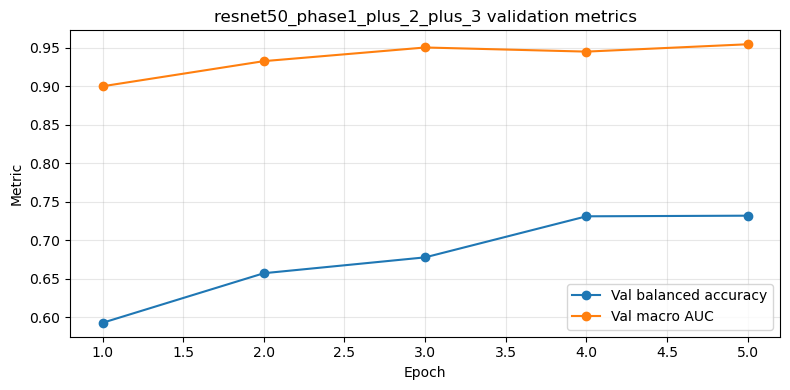

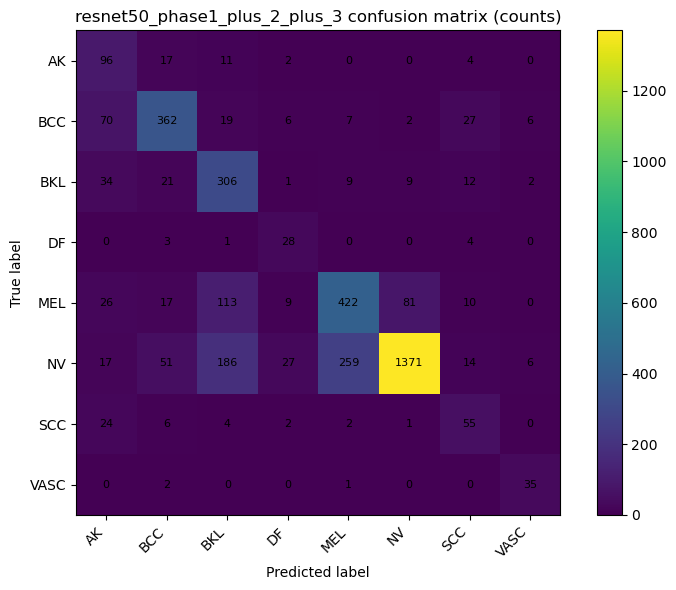

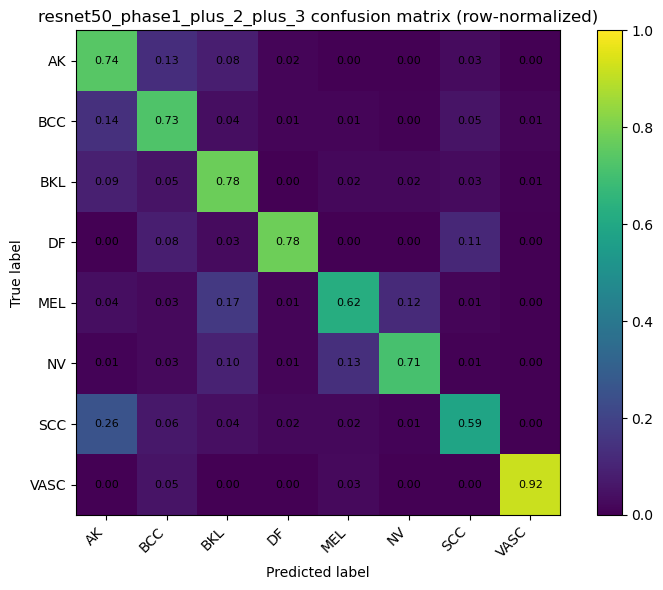

In [27]:
resnet50_phase123_result = run_ablation_experiment(
    backbone="resnet50",
    stage_name="phase1_plus_2_plus_3",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=resnet50, stage=phase1_plus_2_plus_3_plus_4, epochs=5
Active phases: phase1 + phase2 + phase3 + phase4
Train size: 21531
Validation size: 3800
Use CutMix: True
resnet50 | phase1_plus_2_plus_3_plus_4 | Epoch 01/05 | train_size=21531 | train_loss=1.5770 | val_loss=1.1011 | val_bal_acc=0.6078 | val_macro_auc=0.9182 | epoch_time=6.27 min
resnet50 | phase1_plus_2_plus_3_plus_4 | Epoch 02/05 | train_size=21531 | train_loss=1.3002 | val_loss=1.0723 | val_bal_acc=0.6280 | val_macro_auc=0.9208 | epoch_time=6.16 min
resnet50 | phase1_plus_2_plus_3_plus_4 | Epoch 03/05 | train_size=21531 | train_loss=1.1417 | val_loss=0.8465 | val_bal_acc=0.7138 | val_macro_auc=0.9438 | epoch_time=6.22 min
resnet50 | phase1_plus_2_plus_3_plus_4 | Epoch 04/05 | train_size=21531 | train_loss=1.0735 | val_loss=0.8525 | val_bal_acc=0.7003 | val_macro_auc=0.9417 | epoch_time=6.08 min
resnet50 | phase1_plus_2_plus_3_plus_4 | Epoch 05/05 | train_size=21531 | train_loss=1.0142 | val_loss=0.8093 | val_bal

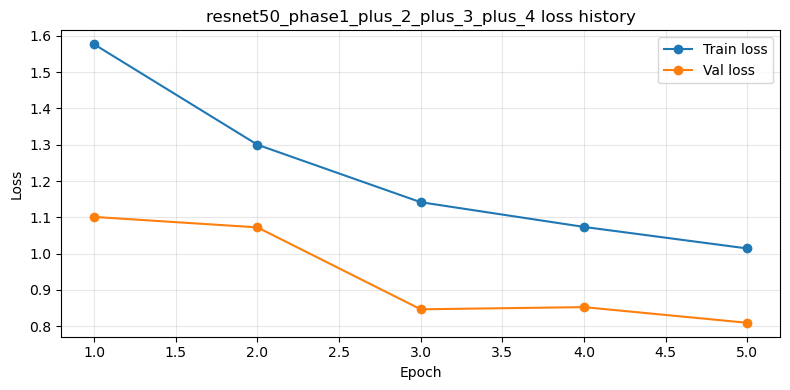

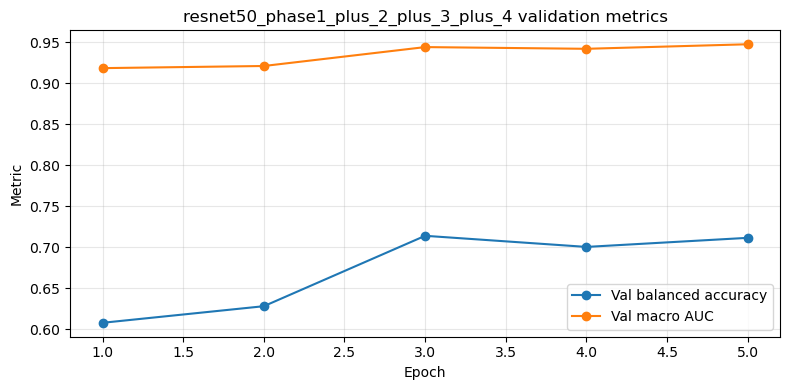

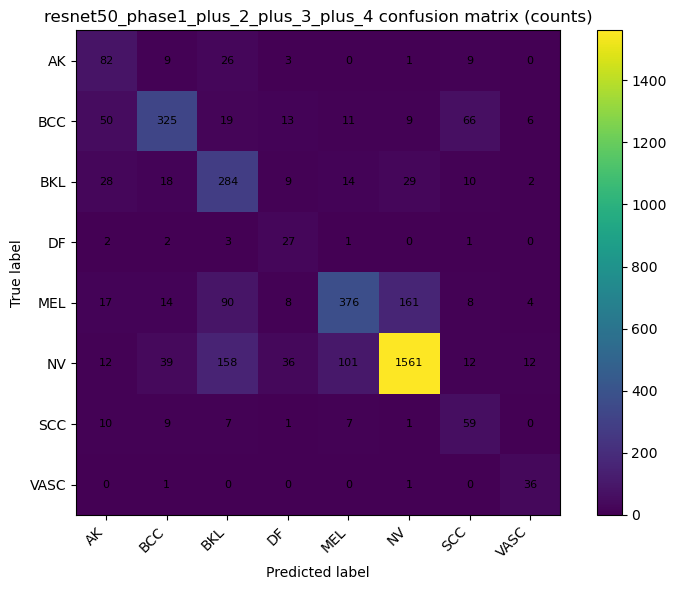

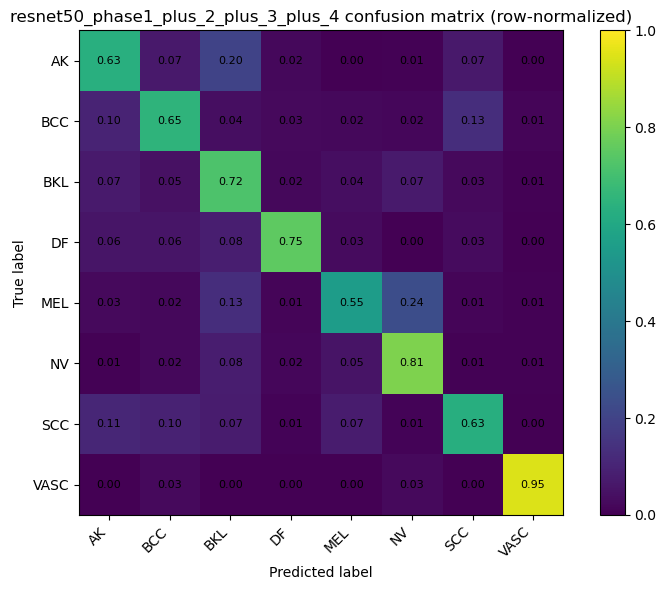

In [28]:
resnet50_phase1234_result = run_ablation_experiment(
    backbone="resnet50",
    stage_name="phase1_plus_2_plus_3_plus_4",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=efficientnet_b0, stage=baseline, epochs=5
Active phases: phase1
Train size: 21531
Validation size: 3800
Use CutMix: False
efficientnet_b0 | baseline | Epoch 01/05 | train_size=21531 | train_loss=1.3536 | val_loss=0.9498 | val_bal_acc=0.6699 | val_macro_auc=0.9295 | epoch_time=5.27 min
efficientnet_b0 | baseline | Epoch 02/05 | train_size=21531 | train_loss=0.8335 | val_loss=0.7409 | val_bal_acc=0.7285 | val_macro_auc=0.9511 | epoch_time=5.25 min
efficientnet_b0 | baseline | Epoch 03/05 | train_size=21531 | train_loss=0.6081 | val_loss=0.7097 | val_bal_acc=0.7533 | val_macro_auc=0.9580 | epoch_time=5.13 min
efficientnet_b0 | baseline | Epoch 04/05 | train_size=21531 | train_loss=0.4740 | val_loss=0.6777 | val_bal_acc=0.7703 | val_macro_auc=0.9631 | epoch_time=5.18 min
efficientnet_b0 | baseline | Epoch 05/05 | train_size=21531 | train_loss=0.3692 | val_loss=0.6962 | val_bal_acc=0.7776 | val_macro_auc=0.9622 | epoch_time=5.26 min


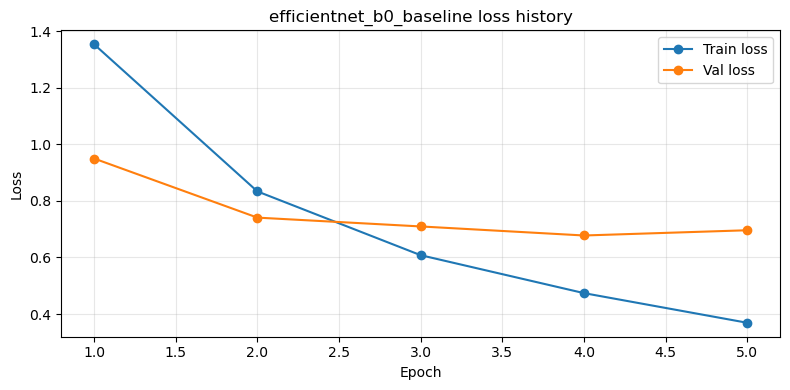

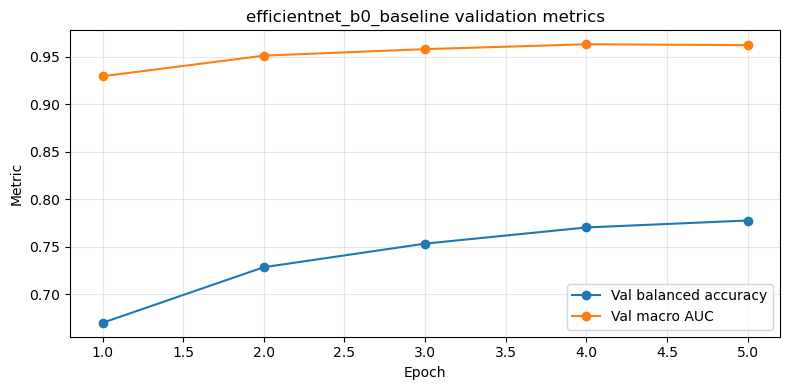

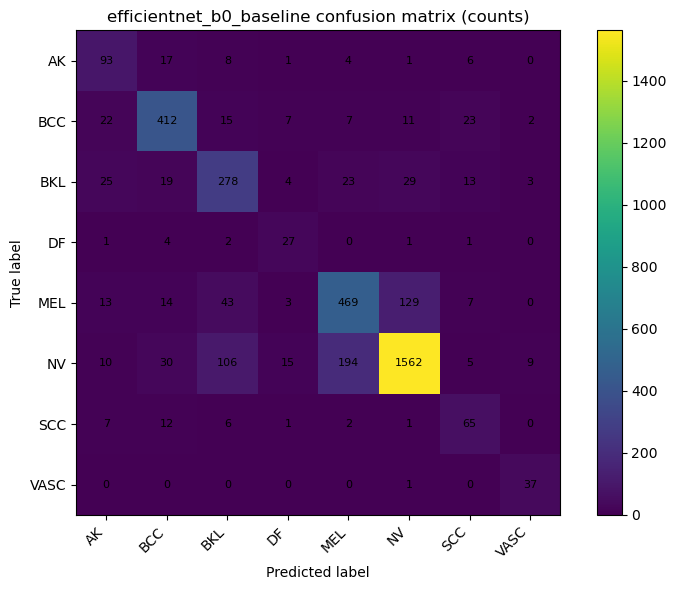

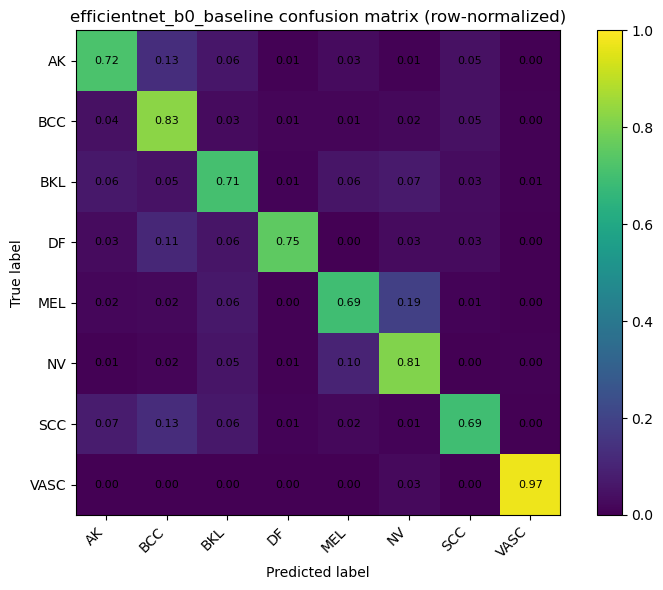

In [29]:
efficientnet_b0_phase1_result = run_ablation_experiment(
    backbone="efficientnet_b0",
    stage_name="baseline",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=efficientnet_b0, stage=phase1_plus_2, epochs=5
Active phases: phase1 + phase2
Train size: 21531
Validation size: 3800
Use CutMix: False
efficientnet_b0 | phase1_plus_2 | Epoch 01/05 | train_size=21531 | train_loss=1.3751 | val_loss=0.9549 | val_bal_acc=0.6683 | val_macro_auc=0.9317 | epoch_time=5.23 min
efficientnet_b0 | phase1_plus_2 | Epoch 02/05 | train_size=21531 | train_loss=0.9403 | val_loss=0.7782 | val_bal_acc=0.7276 | val_macro_auc=0.9480 | epoch_time=5.33 min
efficientnet_b0 | phase1_plus_2 | Epoch 03/05 | train_size=21531 | train_loss=0.7734 | val_loss=0.7358 | val_bal_acc=0.7526 | val_macro_auc=0.9547 | epoch_time=5.14 min
efficientnet_b0 | phase1_plus_2 | Epoch 04/05 | train_size=21531 | train_loss=0.6696 | val_loss=0.6614 | val_bal_acc=0.7561 | val_macro_auc=0.9601 | epoch_time=5.19 min
efficientnet_b0 | phase1_plus_2 | Epoch 05/05 | train_size=21531 | train_loss=0.5965 | val_loss=0.6618 | val_bal_acc=0.7743 | val_macro_auc=0.9626 | epoch_time=5.13 min


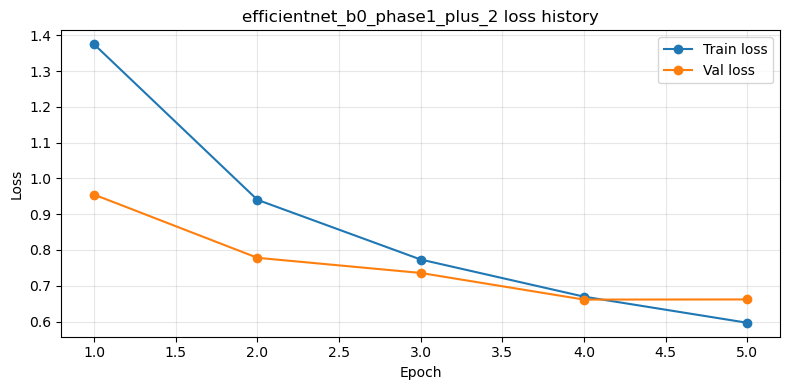

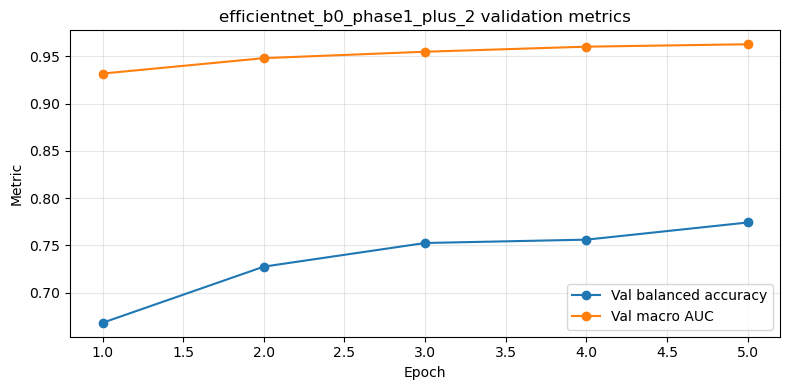

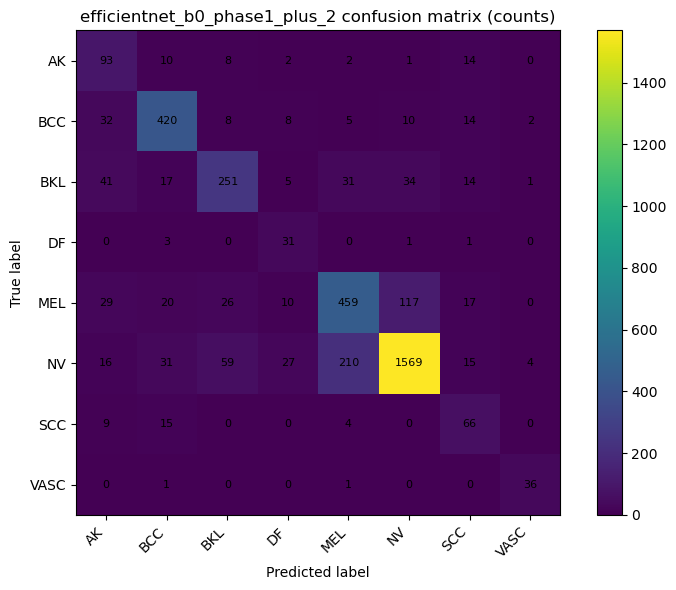

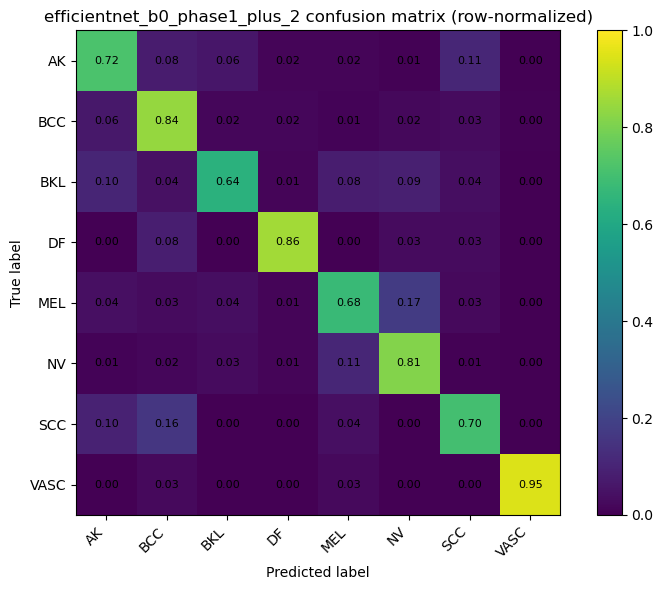

In [30]:
efficientnet_b0_phase12_result = run_ablation_experiment(
    backbone="efficientnet_b0",
    stage_name="phase1_plus_2",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=efficientnet_b0, stage=phase1_plus_2_plus_3, epochs=5
Active phases: phase1 + phase2 + phase3
Train size: 21531
Validation size: 3800
Use CutMix: False
efficientnet_b0 | phase1_plus_2_plus_3 | Epoch 01/05 | train_size=21531 | train_loss=1.4087 | val_loss=0.9887 | val_bal_acc=0.6456 | val_macro_auc=0.9267 | epoch_time=5.55 min
efficientnet_b0 | phase1_plus_2_plus_3 | Epoch 02/05 | train_size=21531 | train_loss=1.0013 | val_loss=0.8121 | val_bal_acc=0.7236 | val_macro_auc=0.9435 | epoch_time=5.51 min
efficientnet_b0 | phase1_plus_2_plus_3 | Epoch 03/05 | train_size=21531 | train_loss=0.8505 | val_loss=0.7698 | val_bal_acc=0.7349 | val_macro_auc=0.9488 | epoch_time=5.63 min
efficientnet_b0 | phase1_plus_2_plus_3 | Epoch 04/05 | train_size=21531 | train_loss=0.7414 | val_loss=0.7069 | val_bal_acc=0.7595 | val_macro_auc=0.9577 | epoch_time=5.61 min
efficientnet_b0 | phase1_plus_2_plus_3 | Epoch 05/05 | train_size=21531 | train_loss=0.6768 | val_loss=0.6866 | val_bal_acc=0.7

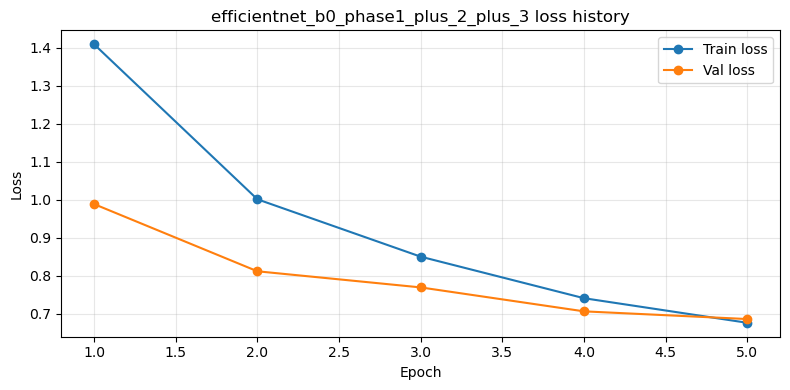

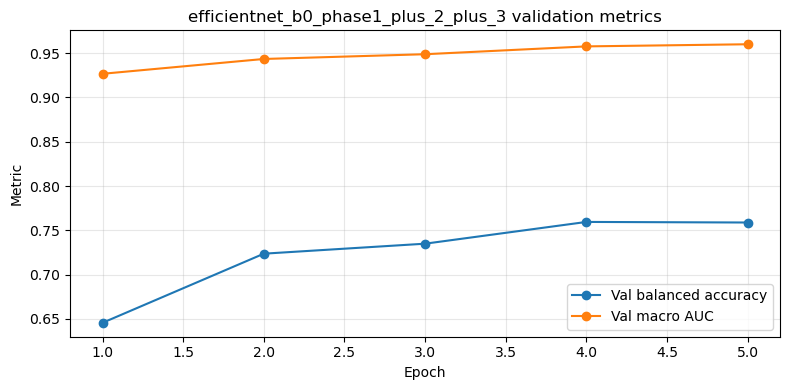

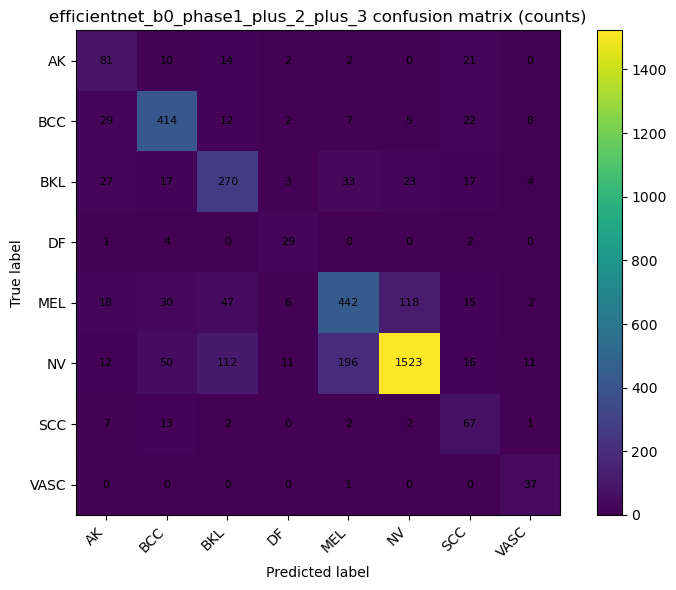

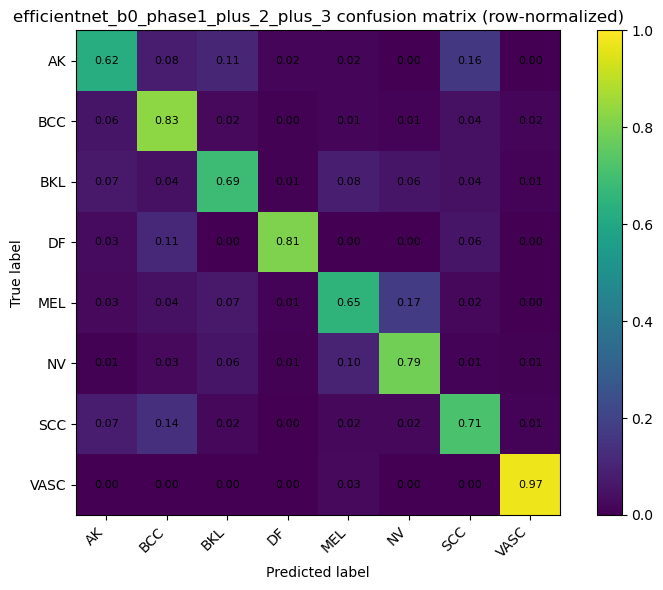

In [31]:
efficientnet_b0_phase123_result = run_ablation_experiment(
    backbone="efficientnet_b0",
    stage_name="phase1_plus_2_plus_3",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=efficientnet_b0, stage=phase1_plus_2_plus_3_plus_4, epochs=5
Active phases: phase1 + phase2 + phase3 + phase4
Train size: 21531
Validation size: 3800
Use CutMix: True
efficientnet_b0 | phase1_plus_2_plus_3_plus_4 | Epoch 01/05 | train_size=21531 | train_loss=1.6259 | val_loss=1.1288 | val_bal_acc=0.6139 | val_macro_auc=0.9145 | epoch_time=5.86 min
efficientnet_b0 | phase1_plus_2_plus_3_plus_4 | Epoch 02/05 | train_size=21531 | train_loss=1.3291 | val_loss=0.9411 | val_bal_acc=0.6725 | val_macro_auc=0.9347 | epoch_time=5.74 min
efficientnet_b0 | phase1_plus_2_plus_3_plus_4 | Epoch 03/05 | train_size=21531 | train_loss=1.2456 | val_loss=0.8676 | val_bal_acc=0.6978 | val_macro_auc=0.9396 | epoch_time=5.85 min
efficientnet_b0 | phase1_plus_2_plus_3_plus_4 | Epoch 04/05 | train_size=21531 | train_loss=1.1811 | val_loss=0.8094 | val_bal_acc=0.7267 | val_macro_auc=0.9429 | epoch_time=5.79 min
efficientnet_b0 | phase1_plus_2_plus_3_plus_4 | Epoch 05/05 | train_size=21531 | tra

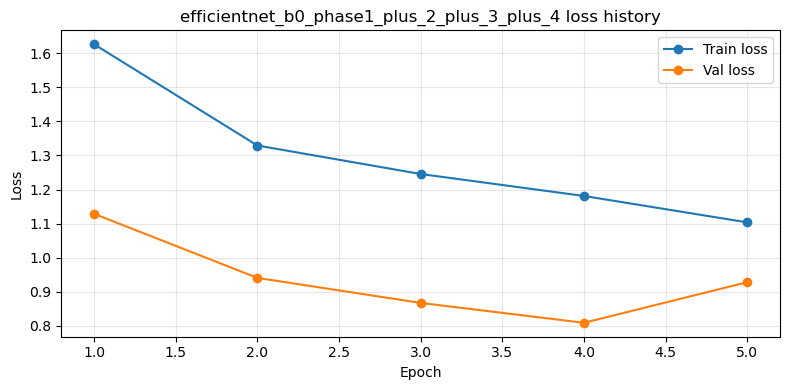

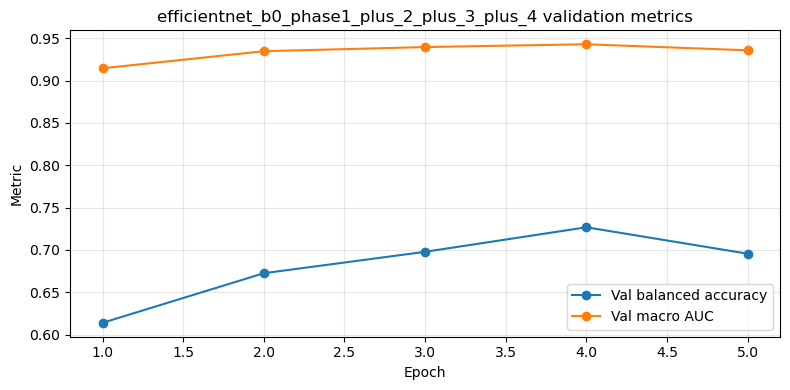

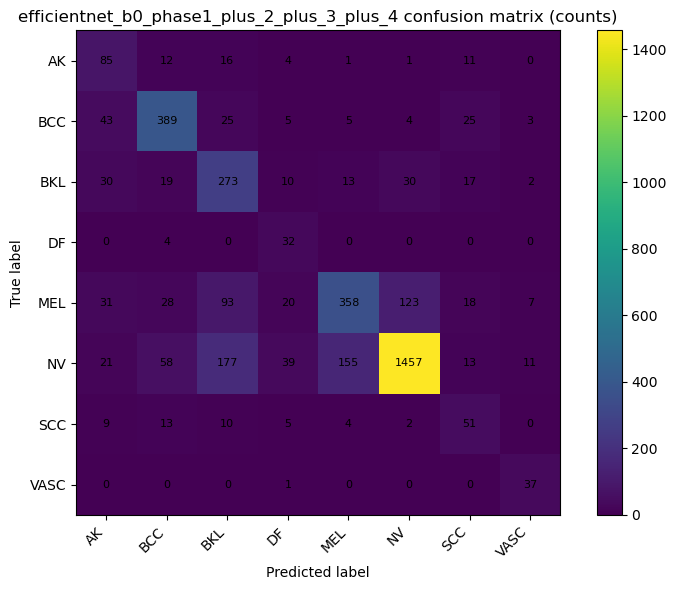

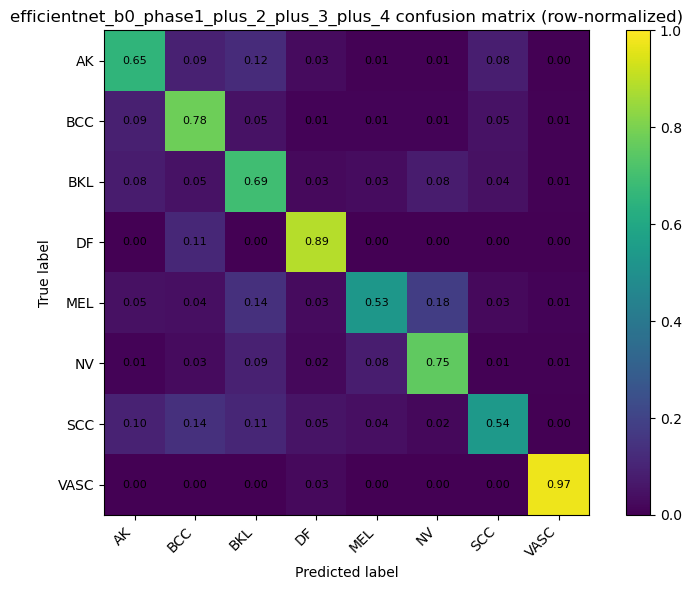

In [32]:
efficientnet_b0_phase1234_result = run_ablation_experiment(
    backbone="efficientnet_b0",
    stage_name="phase1_plus_2_plus_3_plus_4",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=densenet121, stage=baseline, epochs=5
Active phases: phase1
Train size: 21531
Validation size: 3800
Use CutMix: False
densenet121 | baseline | Epoch 01/05 | train_size=21531 | train_loss=1.2299 | val_loss=0.9686 | val_bal_acc=0.6595 | val_macro_auc=0.9305 | epoch_time=5.67 min
densenet121 | baseline | Epoch 02/05 | train_size=21531 | train_loss=0.7995 | val_loss=0.8863 | val_bal_acc=0.6843 | val_macro_auc=0.9390 | epoch_time=5.84 min
densenet121 | baseline | Epoch 03/05 | train_size=21531 | train_loss=0.5461 | val_loss=0.7964 | val_bal_acc=0.7371 | val_macro_auc=0.9522 | epoch_time=5.72 min
densenet121 | baseline | Epoch 04/05 | train_size=21531 | train_loss=0.4065 | val_loss=0.8888 | val_bal_acc=0.7092 | val_macro_auc=0.9528 | epoch_time=5.66 min
densenet121 | baseline | Epoch 05/05 | train_size=21531 | train_loss=0.3167 | val_loss=0.8041 | val_bal_acc=0.7416 | val_macro_auc=0.9563 | epoch_time=5.73 min


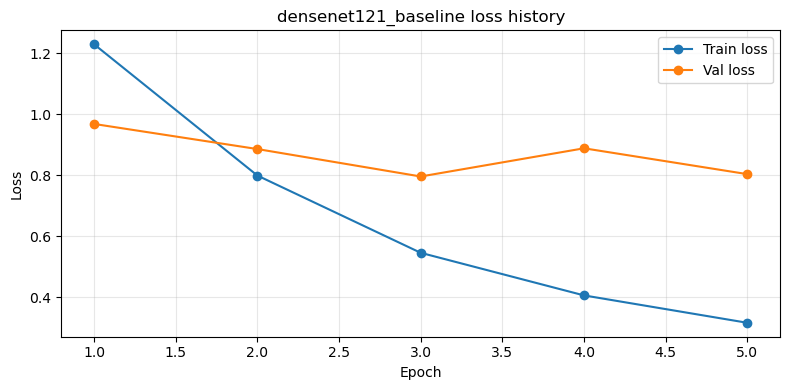

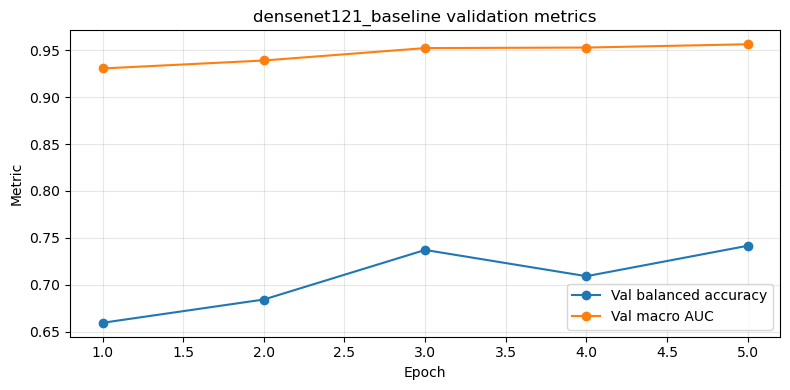

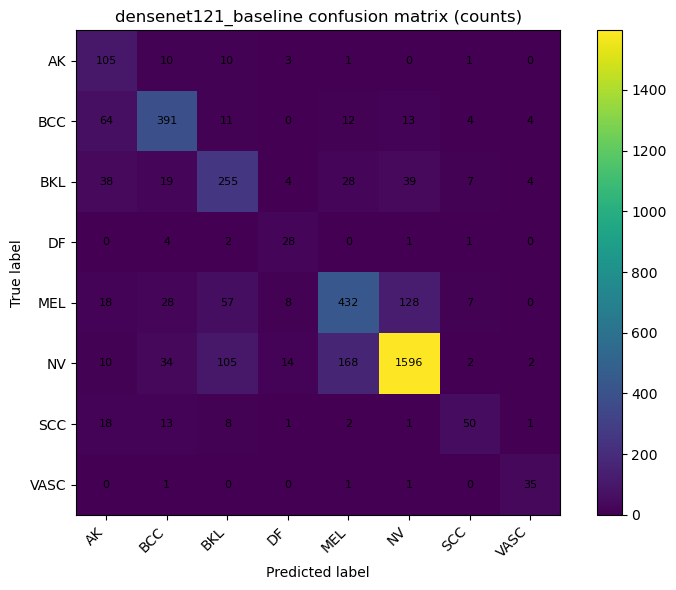

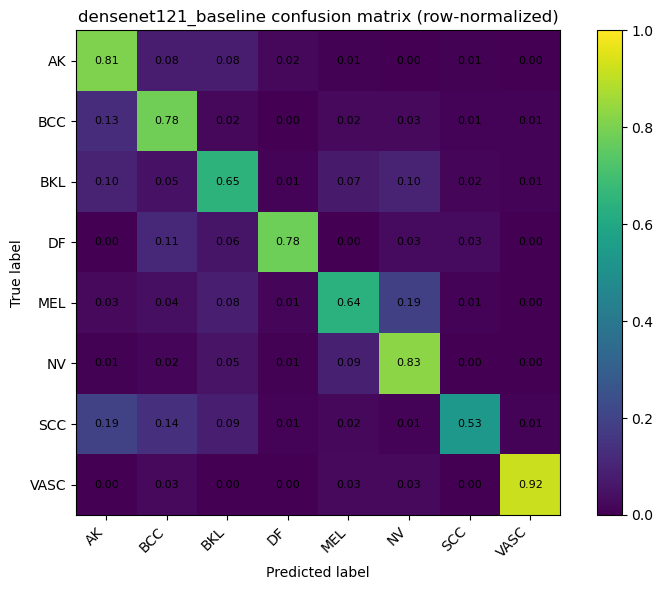

In [33]:
densenet121_phase1_result = run_ablation_experiment(
    backbone="densenet121",
    stage_name="baseline",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=densenet121, stage=phase1_plus_2, epochs=5
Active phases: phase1 + phase2
Train size: 21531
Validation size: 3800
Use CutMix: False
densenet121 | phase1_plus_2 | Epoch 01/05 | train_size=21531 | train_loss=1.2644 | val_loss=0.9870 | val_bal_acc=0.6398 | val_macro_auc=0.9251 | epoch_time=5.72 min
densenet121 | phase1_plus_2 | Epoch 02/05 | train_size=21531 | train_loss=0.9435 | val_loss=0.8471 | val_bal_acc=0.6905 | val_macro_auc=0.9436 | epoch_time=5.63 min
densenet121 | phase1_plus_2 | Epoch 03/05 | train_size=21531 | train_loss=0.8035 | val_loss=0.8306 | val_bal_acc=0.7179 | val_macro_auc=0.9493 | epoch_time=5.72 min
densenet121 | phase1_plus_2 | Epoch 04/05 | train_size=21531 | train_loss=0.7107 | val_loss=0.7491 | val_bal_acc=0.7367 | val_macro_auc=0.9550 | epoch_time=5.70 min
densenet121 | phase1_plus_2 | Epoch 05/05 | train_size=21531 | train_loss=0.6259 | val_loss=0.8069 | val_bal_acc=0.7133 | val_macro_auc=0.9445 | epoch_time=5.86 min


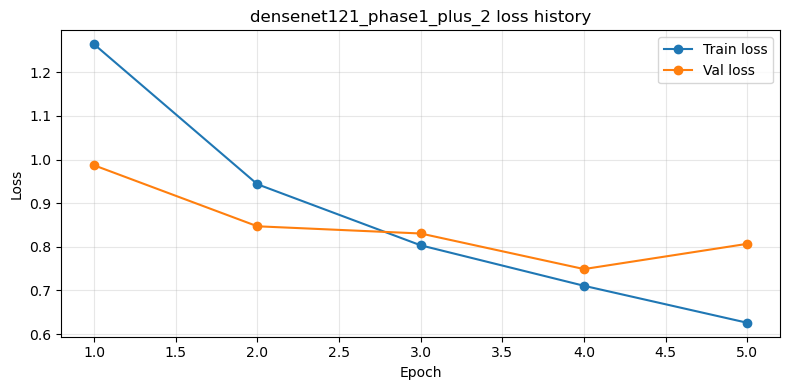

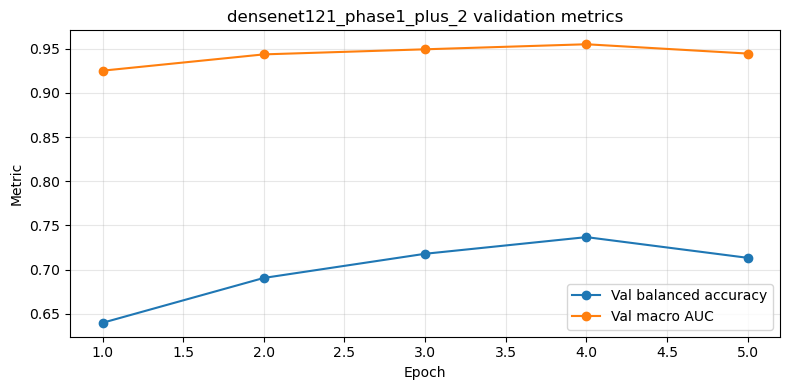

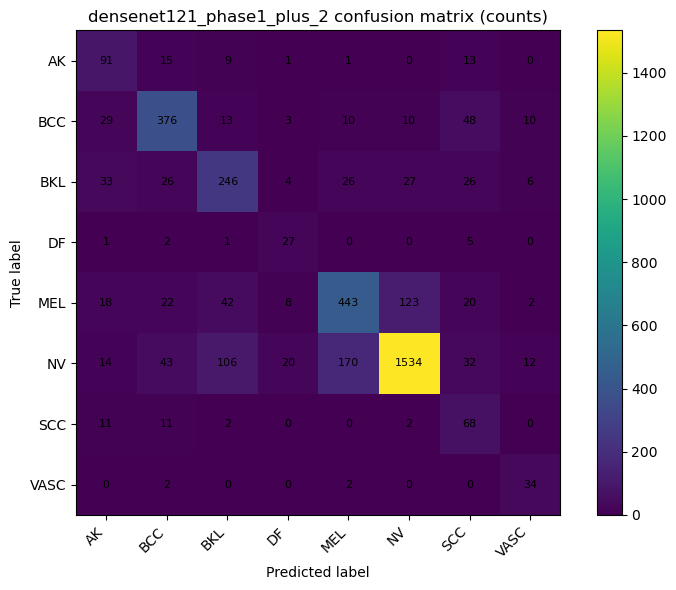

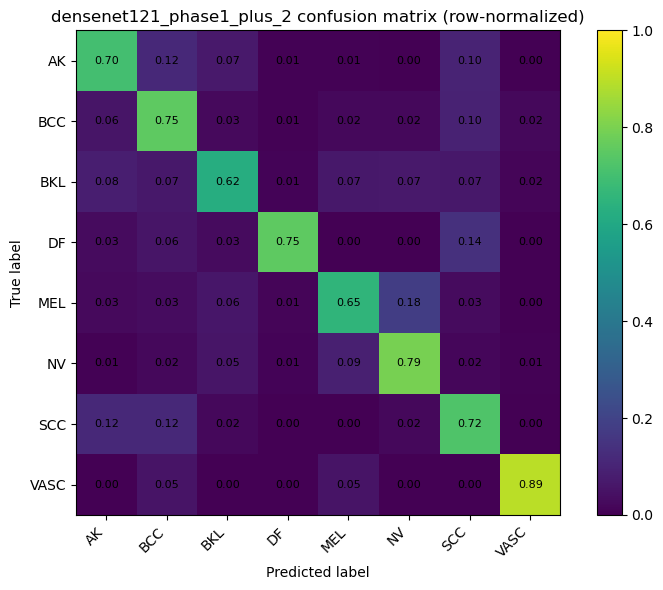

In [34]:
densenet121_phase12_result = run_ablation_experiment(
    backbone="densenet121",
    stage_name="phase1_plus_2",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=densenet121, stage=phase1_plus_2_plus_3, epochs=5
Active phases: phase1 + phase2 + phase3
Train size: 21531
Validation size: 3800
Use CutMix: False
densenet121 | phase1_plus_2_plus_3 | Epoch 01/05 | train_size=21531 | train_loss=1.3318 | val_loss=1.1002 | val_bal_acc=0.6120 | val_macro_auc=0.9095 | epoch_time=6.06 min
densenet121 | phase1_plus_2_plus_3 | Epoch 02/05 | train_size=21531 | train_loss=1.0182 | val_loss=0.9343 | val_bal_acc=0.6711 | val_macro_auc=0.9339 | epoch_time=6.03 min
densenet121 | phase1_plus_2_plus_3 | Epoch 03/05 | train_size=21531 | train_loss=0.8676 | val_loss=0.8369 | val_bal_acc=0.7120 | val_macro_auc=0.9413 | epoch_time=6.14 min
densenet121 | phase1_plus_2_plus_3 | Epoch 04/05 | train_size=21531 | train_loss=0.7863 | val_loss=0.7967 | val_bal_acc=0.7121 | val_macro_auc=0.9529 | epoch_time=5.98 min
densenet121 | phase1_plus_2_plus_3 | Epoch 05/05 | train_size=21531 | train_loss=0.7118 | val_loss=0.7763 | val_bal_acc=0.7217 | val_macro_auc=0.95

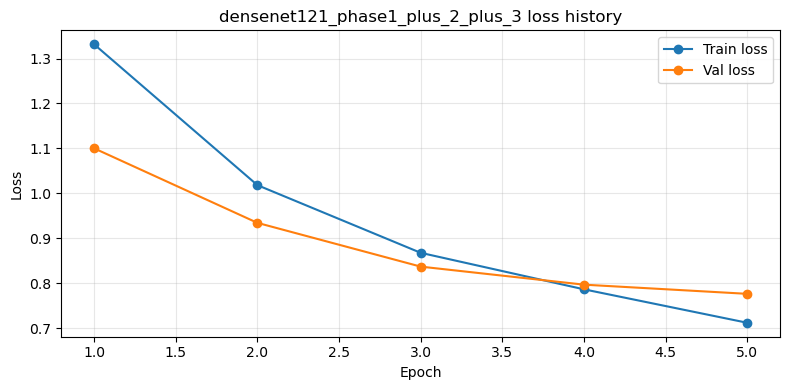

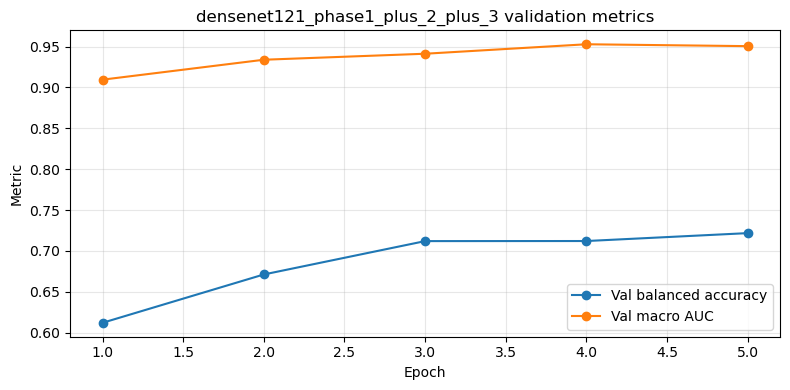

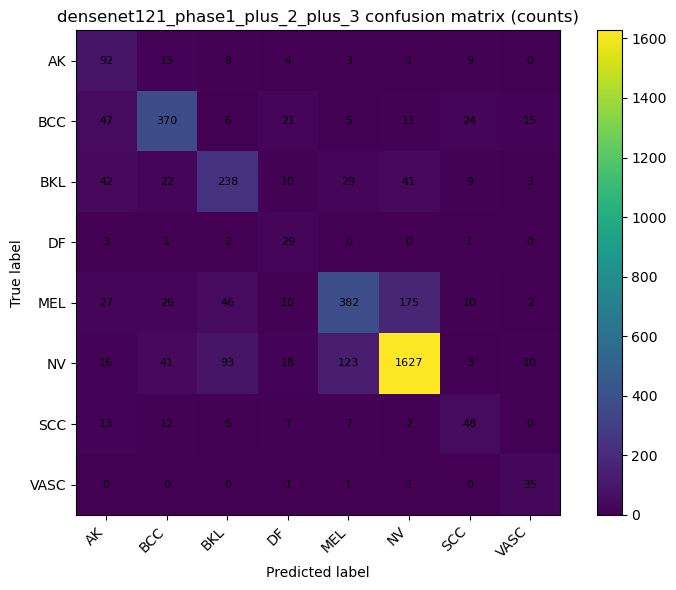

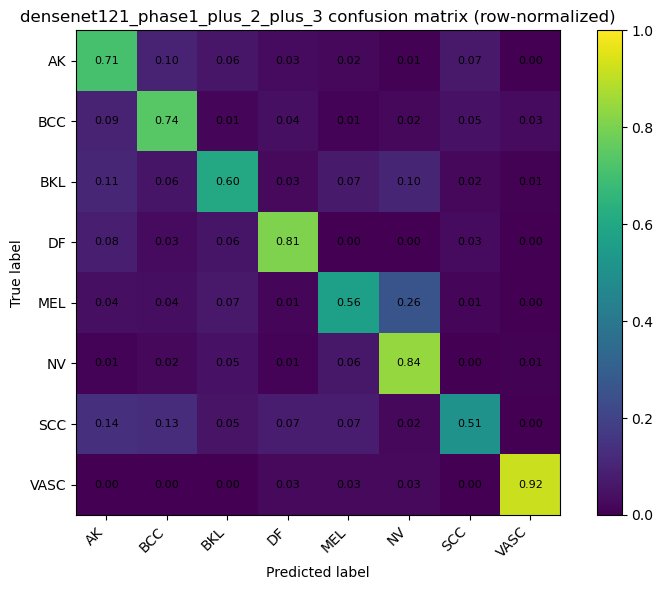

In [35]:
densenet121_phase123_result = run_ablation_experiment(
    backbone="densenet121",
    stage_name="phase1_plus_2_plus_3",
    epochs=FULL_RUN_EPOCHS,
)

Running backbone=densenet121, stage=phase1_plus_2_plus_3_plus_4, epochs=5
Active phases: phase1 + phase2 + phase3 + phase4
Train size: 21531
Validation size: 3800
Use CutMix: True
densenet121 | phase1_plus_2_plus_3_plus_4 | Epoch 01/05 | train_size=21531 | train_loss=1.5625 | val_loss=1.2275 | val_bal_acc=0.5528 | val_macro_auc=0.8877 | epoch_time=6.31 min
densenet121 | phase1_plus_2_plus_3_plus_4 | Epoch 02/05 | train_size=21531 | train_loss=1.3205 | val_loss=1.0159 | val_bal_acc=0.6228 | val_macro_auc=0.9244 | epoch_time=6.32 min
densenet121 | phase1_plus_2_plus_3_plus_4 | Epoch 03/05 | train_size=21531 | train_loss=1.2605 | val_loss=0.9291 | val_bal_acc=0.6797 | val_macro_auc=0.9296 | epoch_time=6.49 min
densenet121 | phase1_plus_2_plus_3_plus_4 | Epoch 04/05 | train_size=21531 | train_loss=1.1768 | val_loss=0.9737 | val_bal_acc=0.6721 | val_macro_auc=0.9257 | epoch_time=6.31 min
densenet121 | phase1_plus_2_plus_3_plus_4 | Epoch 05/05 | train_size=21531 | train_loss=1.0966 | val_los

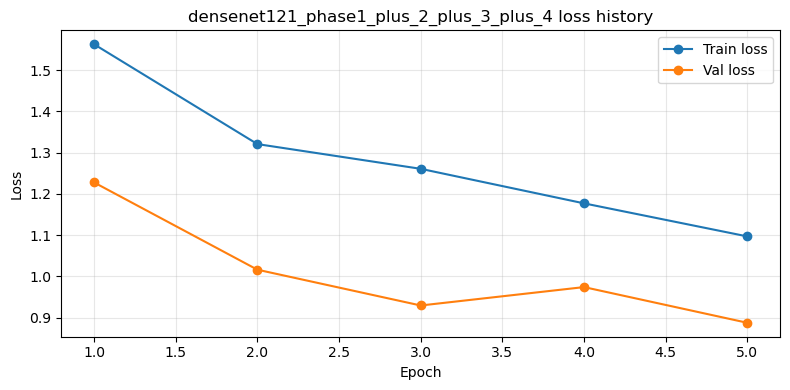

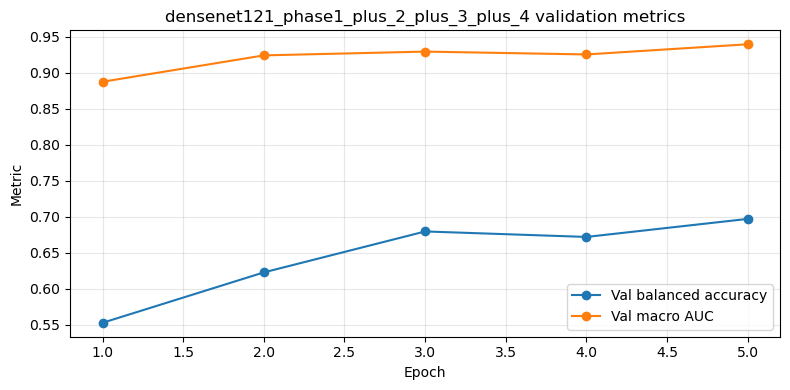

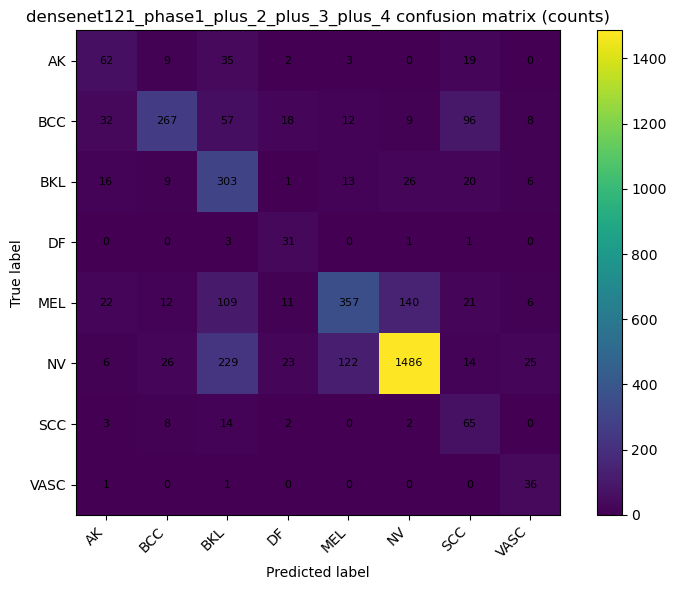

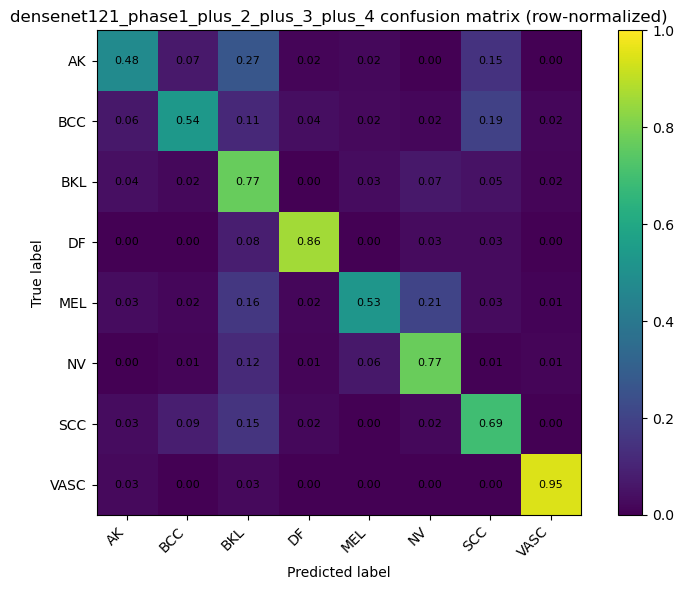

In [36]:
densenet121_phase1234_result = run_ablation_experiment(
    backbone="densenet121",
    stage_name="phase1_plus_2_plus_3_plus_4",
    epochs=FULL_RUN_EPOCHS,
)

In [37]:
all_results = [
    resnet50_phase1_result,
    resnet50_phase12_result,
    resnet50_phase123_result,
    resnet50_phase1234_result,

    efficientnet_b0_phase1_result,
    efficientnet_b0_phase12_result,
    efficientnet_b0_phase123_result,
    efficientnet_b0_phase1234_result,

    densenet121_phase1_result,
    densenet121_phase12_result,
    densenet121_phase123_result,
    densenet121_phase1234_result,
]

results_df = pd.DataFrame(all_results)
display(results_df)

out_path = METRIC_DIR / "ablation_full_comparison.csv"
results_df.to_csv(out_path, index=False)

print("Saved aggregated results to:", out_path)

,backbone,stage,epochs_requested,train_size,combined_train_size,val_size,active_phases,augmentation_mode,use_cutmix,best_epoch,...,auc_BKL,auc_DF,auc_MEL,auc_NV,auc_SCC,auc_VASC,history_path,pred_path,report_path,checkpoint_path
0,resnet50,baseline,5,21531,21531,3800,phase1,on_the_fly_cumulative_transform,False,5,...,0.930959,0.972665,0.905116,0.944488,0.954559,0.997391,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,resnet50,phase1_plus_2,5,21531,21531,3800,phase1+phase2,on_the_fly_cumulative_transform,False,5,...,0.931320,0.992244,0.891334,0.946635,0.965232,0.997901,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,phase1_plus_2_plus_3,5,21531,21531,3800,phase1+phase2+phase3,on_the_fly_cumulative_transform,False,5,...,0.928634,0.992081,0.887064,0.947042,0.952963,0.991907,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
3,resnet50,phase1_plus_2_plus_3_plus_4,5,21531,21531,3800,phase1+phase2+phase3+phase4,on_the_fly_cumulative_transform,True,5,...,0.913339,0.962053,0.893868,0.935338,0.968920,0.995803,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
4,efficientnet_b0,baseline,5,21531,21531,3800,phase1,on_the_fly_cumulative_transform,False,4,...,0.926541,0.993520,0.914086,0.948779,0.966058,0.999496,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
5,efficientnet_b0,phase1_plus_2,5,21531,21531,3800,phase1+phase2,on_the_fly_cumulative_transform,False,5,...,0.937919,0.989189,0.904623,0.946966,0.973533,0.999217,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
6,efficientnet_b0,phase1_plus_2_plus_3,5,21531,21531,3800,phase1+phase2+phase3,on_the_fly_cumulative_transform,False,5,...,0.918911,0.992428,0.905546,0.946471,0.973169,0.999328,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
7,efficientnet_b0,phase1_plus_2_plus_3_plus_4,5,21531,21531,3800,phase1+phase2+phase3+phase4,on_the_fly_cumulative_transform,True,4,...,0.885999,0.988480,0.867425,0.930671,0.952986,0.999070,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
8,densenet121,baseline,5,21531,21531,3800,phase1,on_the_fly_cumulative_transform,False,5,...,0.910653,0.985248,0.896958,0.944933,0.963288,0.999363,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
9,densenet121,phase1_plus_2,5,21531,21531,3800,phase1+phase2,on_the_fly_cumulative_transform,False,4,...,0.907445,0.984015,0.907191,0.940916,0.966851,0.996817,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


Saved aggregated results to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_full_comparison.csv


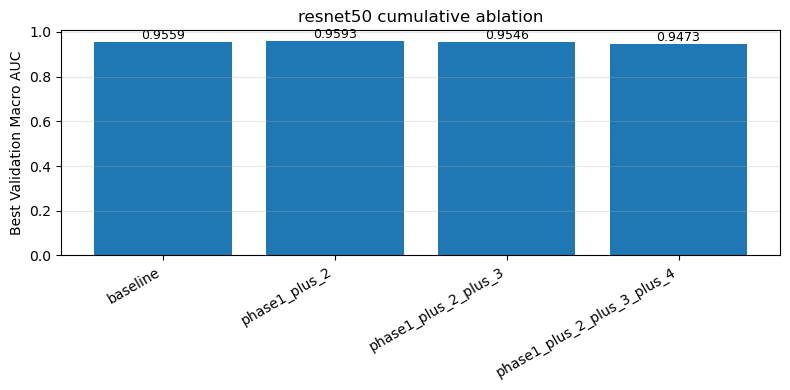

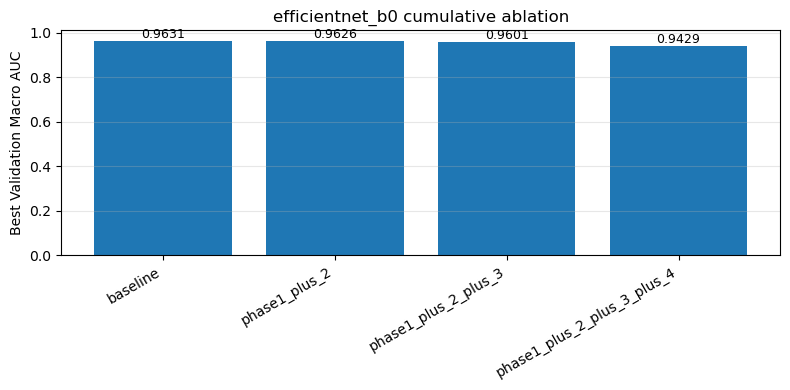

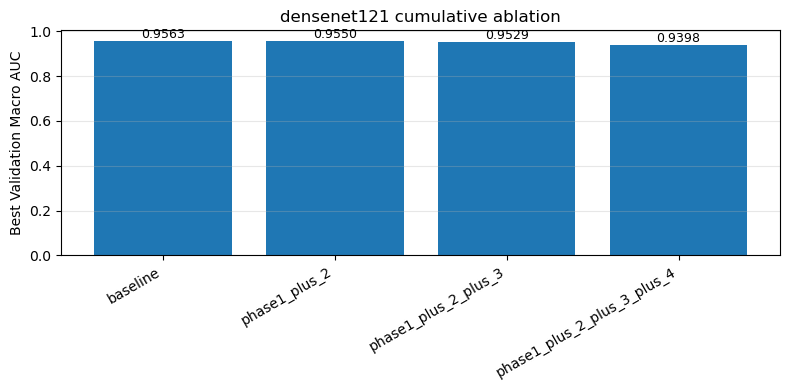

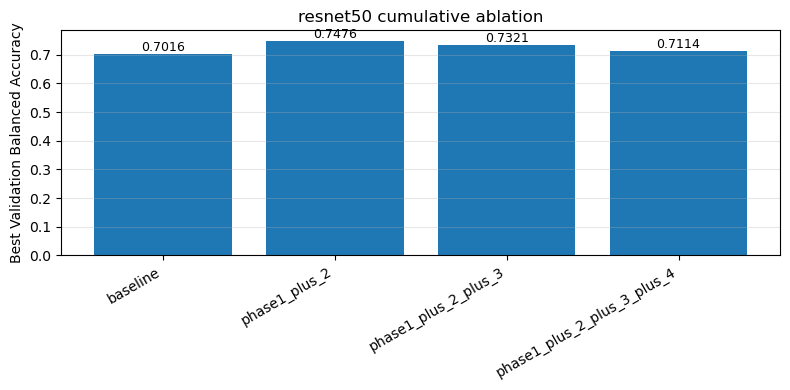

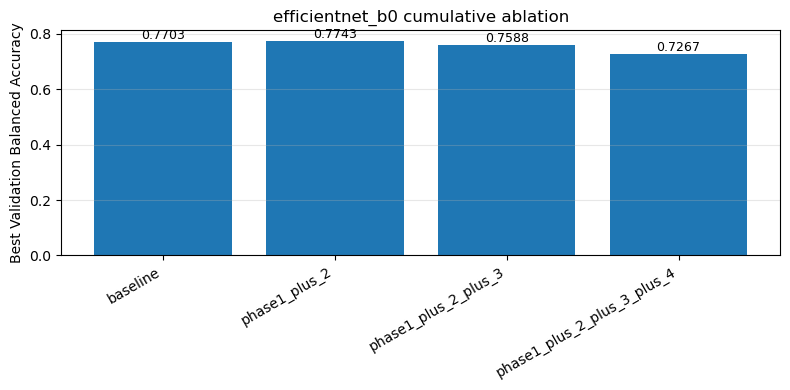

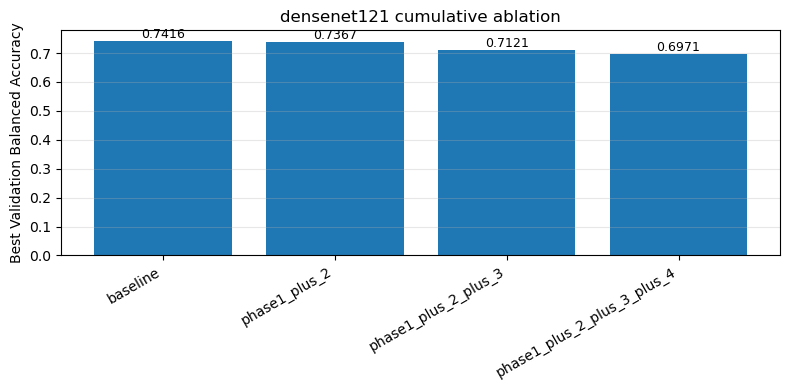

In [38]:
# ==========================================
# BACKBONE-WISE CUMULATIVE COMPARISON PLOTS
# ==========================================

for metric_col, metric_label in [
    ("best_val_macro_auc", "Best Validation Macro AUC"),
    ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
]:
    for backbone in BACKBONES:
        subset = results_df[results_df["backbone"] == backbone].copy()
        if subset.empty:
            continue

        subset["stage"] = pd.Categorical(
            subset["stage"],
            categories=ABLATION_STAGES,
            ordered=True,
        )
        subset = subset.sort_values("stage")

        plt.figure(figsize=(8, 4))
        bars = plt.bar(subset["stage"].astype(str), subset[metric_col])
        plt.ylabel(metric_label)
        plt.title(f"{backbone} cumulative ablation")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)

        for bar, value in zip(bars, subset[metric_col]):
            if pd.notna(value):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.4f}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        plt.tight_layout()
        out_name = f"{backbone}_{metric_col}_ablation.png"
        plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
        plt.show()

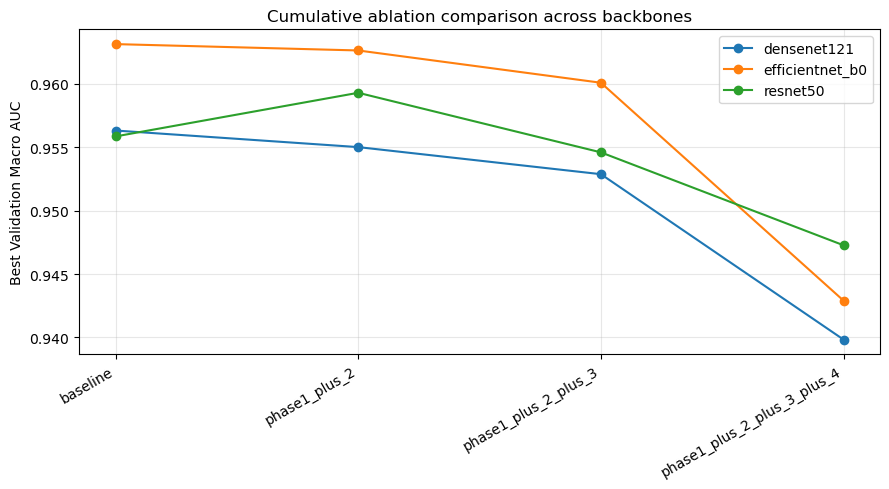

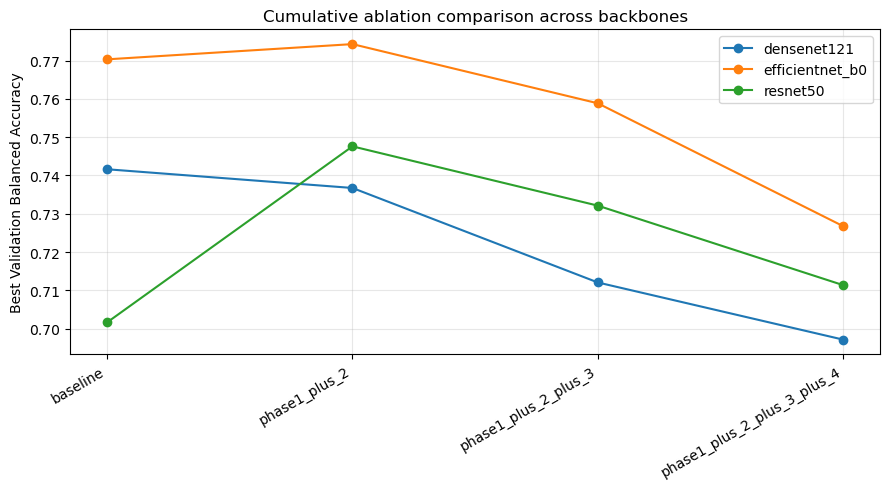

In [39]:
# ==========================================
# CROSS-BACKBONE SUMMARY PLOTS
# ==========================================

for metric_col, metric_label in [
    ("best_val_macro_auc", "Best Validation Macro AUC"),
    ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
]:
    pivot_df = results_df.pivot(
        index="stage",
        columns="backbone",
        values=metric_col,
    ).reindex(ABLATION_STAGES)

    plt.figure(figsize=(9, 5))
    for backbone in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[backbone], marker="o", label=backbone)

    plt.ylabel(metric_label)
    plt.title(f"Cumulative ablation comparison across backbones")
    plt.xticks(rotation=30, ha="right")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_name = f"cross_backbone_{metric_col}_ablation.png"
    plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
    plt.show()

In [40]:
# ==========================================
# BEST-STAGE SUMMARY BY BACKBONE
# ==========================================

best_by_auc = (
    results_df.sort_values(
        by=["best_val_macro_auc", "best_val_balanced_accuracy"],
        ascending=False,
    )
    .groupby("backbone", as_index=False)
    .first()
)

display(best_by_auc)

best_by_auc_out = METRIC_DIR / (
    "ablation_best_stage_by_backbone_smoke.csv"
    if SMOKE_MODE else
    "ablation_best_stage_by_backbone_full.csv"
)
best_by_auc.to_csv(best_by_auc_out, index=False)

print("Saved best-stage summary to:", best_by_auc_out)

,backbone,stage,epochs_requested,train_size,combined_train_size,val_size,active_phases,augmentation_mode,use_cutmix,best_epoch,...,auc_BKL,auc_DF,auc_MEL,auc_NV,auc_SCC,auc_VASC,history_path,pred_path,report_path,checkpoint_path
0,densenet121,baseline,5,21531,21531,3800,phase1,on_the_fly_cumulative_transform,False,5,...,0.910653,0.985248,0.896958,0.944933,0.963288,0.999363,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,efficientnet_b0,baseline,5,21531,21531,3800,phase1,on_the_fly_cumulative_transform,False,4,...,0.926541,0.993520,0.914086,0.948779,0.966058,0.999496,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,phase1_plus_2,5,21531,21531,3800,phase1+phase2,on_the_fly_cumulative_transform,False,5,...,0.931320,0.992244,0.891334,0.946635,0.965232,0.997901,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


Saved best-stage summary to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_best_stage_by_backbone_full.csv
